### __Group Assignment - Predicting Listed Used Car Prices__

---

**Kaggle Competition Ends:** Friday, 31 October 2025 @ 3:00pm (Week 12)  
**Assignment Due Date on iLearn:** Friday, 31 October 2025 @ 11.55pm (Week 12)  
**In Person Presentation Due:** (Week 13)  

**Total Marks:** 30

**Overview:**   

- In the group assignment you will form a team of 3 students and participate in a forecasting competition on Kaggle


**Instructions:**

- Form a team of 3 students
- Each team member needs to join [https://www.kaggle.com](https://www.kaggle.com/)  
- Choose a team leader and form a team on Kaggle [https://www.kaggle.com/competitions/asba-predictive-analytics-competition-s-2-2025/host](https://www.kaggle.com/t/6285d38ad6d4408d86e9fe8e006dada3)
    - Team leader to click on `team` and invite other 2 team members to join
    - Your **team's name must start** with our unit code
- All team members should work on all the tasks however   
    - Each team member will be responsible for one of the 3 tasks listed below    
- **Your predictions must be generated by a model you develop here**
    - You will receive a mark of **zero** if your code is not able produce the forecasts you submit to Kaggle

**Competition Rankings**

The rankings for the competition are determined through two different leaderboards:

- **Public Leaderboard Ranking**: Available during the competition, these rankings are calculated based on 50% of the test dataset, which includes 2,000 observations. This allows participants to see how they are performing while the competition is still ongoing.
- **Final Leaderboard Ranking**: These rankings are recalculated from the other 50% of the test dataset, which consists of the remaining 2,000 observations, and are revealed 5 minutes after the competition concludes. This final evaluation determines the ultimate standings of the competition.



**Marks**

- Assignment: 30 marks consisting of Solutions (25 marks) + In Person Presentation (5 marks)
- **Each Student's Mark: 50% x overall assignment mark + 50% x mark for the task that you are responsible for**  



**Submissions:**  

1. On Kaggle: submit your team's forecast in order to be ranked by Kaggle
2. On iLearn **only team leader to submit** the assignment Jupyter notebook re-named to your team's name on Kaggle   
    - The Jupyter notebook must contain team members names/ID numbers, and the group name Kaggle
    - 9 minute presentation of your work
        - 5 marks will be deducted from each Task that is not included in your presentation   


---
---

### <span style="background-color: yellow;">**Fill out the following information**

- Team Name on Kaggle: `BUSA8001_That's not my name`
- Team Member 1: `Ha My Dang`
- Team Member 2: `Luong Phuong Anh Pham`
- Team Leader & Team Member 3: `Quoc Phong Nguyen`

---

## Task 1: Problem Description and Initial Data Analysis

- You must clearly explain all your answers in both the Markdown file and in your presentation.

**Total Marks: 8**   

Based on the Competition Overview, datasets and additional information provided on Kaggle, along with insights gained from personal research of the topic, write **Problem Description** (about 500 words) focusing on the sections listed below:
1. Forecasting Problem - explain what we are trying to do and how it could be used in the real world, e.g. who and how may benefit from it (2 marks)    
2. Evaluation Criteria - discuss the criterion that is used in this competition to assess forecasting performance, and its pros and cons. (1 marks)     
3. Categorise all variables provided in the dataset according to their type; Hint: similar to what we had in Programming Task 1 (2 marks)  
4. Missing Values - explain what you find for both the training and test datasets at this stage (2 marks)
5. Provide and discuss some interesting *univariate* data characteristics (e.g. summary statistics and plots) in the training dataset  (1 marks)       
- Hints:
    - You should **not** discuss any specific predictive algorithms at this stage


Student in charge of this task: `Ha My Dang`

### Question 1: Forecasting Problem

The aim of the project is to build a predictive model to forecast the price of used cars based on different attributes. Through the process of understanding the problem, cleaning data, feature engineering, and optimizing regression models, we can arrive at an effective model. Accurate predictions of used cars price are can improve decision-making, promote transparency, and eliminate asymmetric information in the market for second-hand cars.

There are many real world applications for this predictive model

**1. Market Participants**
- **Consumers**: Accurate predictions allow buyers to know which factors determine the price. This can guide their savings plans, purchase timing, and negotiation tactics. Sellers can set realistic listings in line with true market value.
- **Dealerships**: Using predictive price benchmarks, dealers can optimize trade-in offers, pricing strategies, and inventory rotation to ensure optimal stock flow.
- **Fleet Management**: For large-scale consumers, planning acquisitions and disposals strategically can help minimize depreciation lossess, thereby improving financial control.

**2. Market Infrastructure**
- **Digital Auto Platforms**: Predictive pricing tools offer transparent valuation guidance, promoting fair negotiations and trust in listings and sellers.
- **Regulators and Tax Policy-makers**: Use accurate valuation for tax and compliance purposes, ensuring consistency in every transactions.

**3. Market Insights**
- **Manufacturers**: Predicted price patterns support strategic functions. For example, automakers can identify how model, mileage, and other features affect long-term value. This supports product design, marketing, and resale strategies.

### Question 2: Evaluation Criteria

The performance of the regression model is evaluated using the metrics **Mean Absolute Percentage Error (MAPE)** as specified in the `scikit-learn` library. The MAPE is defined as


$$
 MAPE = \frac{1}{n} \sum_{i=0}^{n-1}\frac{|y_i - \hat{y_i}|}{max(\epsilon , |y_i|)}
$$

in which:

- $n$: the number of examples
- $ \hat{y_i}$: the predicted value of the i-th sample
- $y_i$: the corresponding true value
- $ϵ$: an arbitrary but small and strictly positive number to avoid undefined result when y equals to 0

The MAPE assesses the prediction accuracy by measuring the average absolute percentage difference between predicted and actual values. It expresses the error magnitude as a proportion of actual values.

It has several **advantages**:
- Easy to interpret: The MAPE is expressed as a percentage, making intuitive sense of average forecast deviataion.
- Scale-independent: It normalizes error relative to actual values. We can therefore use the metrics to compare forecast accuracy of different models.

But also some **drawbacks**:
- Division by 0 can be problematic: MAPE can be undefined if any actual value is 0 as with the case of sales data (can contain valid 0 values). The scikit-learn module mitigates this by using $ϵ$ term in the denominator.
- Asymmetric penalty: MAPE penalises over-predictions more heavily than under-predictions. As such, under-prediction error is capped at 100% whereas there is no upper bound for predictions above the actual values. This can leads to models being biased towards under-forecasting.
- Sensitivity to small actual values. Very small actual values can lead to disproportionately large percentage errors. This means that outliers can significantly skew the overall MAPE, distorting the actual model performance.

### Question 3: Data Type

In [1]:
#Task 1, Question 3 code
#Import library and data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
#Settings options
#display option
pd.options.display.float_format = '{:,.2f}'.format
#Set display option to show all rows
pd.set_option('display.max_rows', None)
#ignore warning
import warnings
warnings.filterwarnings('ignore')
#color
palette = ["#625E97","#83A7B9","#AED6C6","#AA976F","#C89899"]


# #Import data
train = pd.read_csv("train.csv")
test = pd.read_csv('test.csv')


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vin                   8000 non-null   object 
 1   back_legroom          7993 non-null   object 
 2   body_type             8000 non-null   object 
 3   city                  8000 non-null   object 
 4   city_fuel_economy     8000 non-null   float64
 5   daysonmarket          8000 non-null   int64  
 6   dealer_zip            8000 non-null   int64  
 7   engine_displacement   8000 non-null   float64
 8   engine_type           8000 non-null   object 
 9   exterior_color        7883 non-null   object 
 10  franchise_dealer      7898 non-null   object 
 11  front_legroom         7993 non-null   object 
 12  fuel_type             8000 non-null   object 
 13  height                7993 non-null   object 
 14  highway_fuel_economy  8000 non-null   float64
 15  horsepower           

|Variable Kind|Number of Features|Feature Names
| --- | --- | --- |
| Numeric | 18 | back_legroom, city_fuel_economy, daysonmarket, engine_displacement, front_legroom, height, highway_fuel_economy, horsepower, latitude, longitude, maximum_seating, mileage, power, savings_amount, seller_rating, torque, wheelbase, width|
| Ordinal  | 2 | listed_date, year  |
| Nominal  | 16 | vin, body_type, city, dealer_zip, engine_type, exterior_color, franchise_dealer, fuel_type, interior_color, is_new, listing_color, make_name, model_name, transmission, transmission_display, wheel_system|

**Brief description**:
- The `train` dataset has in total **37** variables. The `test` dataset has in total **36** variables as the `price` variable is not present

However, both the datasets contain several similar features such as:

- There are 18 numeric features which cover mostly vehicle specifications (such as the dimensions of the car), vehicle performance, amount of money saved, and information about the sellers. Among these numeric features, variables such as `back_legroom`, `front_legroom` and so on require cleaning to remove the attached string characters.
- Among the numeric features, there are only 2 discrete variables: `daysonmarket` and `maximum_seating` because they can take on specific values and are counted rather than measured.
- There are 2 ordinal variables: `listed_date` and `year`. They are ordinal because there is an inherent hierarchy to them. For example, 28/11/2020 would have to come after 27/11/2020. Similarly, 2020 is a later year than 2021.
- There are 16 nominal features because they are categorical without any specific order. These features cover the superficial surface of the car, information about car producers, auxillary systems.
- Within the nominal variables, there are also boolean features such as `franchise_dealer` and `is_new`.

### Question 4: Missing values

In [2]:
#Task 1, Question 4 code
#check for missing value in each train and test dataset
train_null = train.isnull().sum()
test_null = test.isnull().sum()
train_null_percentage = train_null / len(train) * 100
test_null_percentage = test_null / len(test) * 100
train_test_null = pd.DataFrame({'train': train_null, 'test': test_null, 'train_pct': train_null_percentage, 'test_pct': test_null_percentage})
train_test_null[train_test_null.sum(axis=1) > 0]

,train,test,train_pct,test_pct
back_legroom,7,32.00,0.09,0.80
city_fuel_economy,0,455.00,0.00,11.38
engine_displacement,0,40.00,0.00,1.00
engine_type,0,72.00,0.00,1.80
exterior_color,117,64.00,1.46,1.60
franchise_dealer,102,46.00,1.27,1.15
front_legroom,7,32.00,0.09,0.80
fuel_type,0,54.00,0.00,1.35
height,7,32.00,0.09,0.80
highway_fuel_economy,0,455.00,0.00,11.38


There are some notable observations on the missing values in both the train and test dataset

**1. The extent of missing data**

- On the `train` dataset, there are **17 variables** with missing values in the train dataset. The `test` dataset, on the other hand, has **24 variables** with missing values. Majority of the missing values are related to features of the vehicles.
- Most of the variables have negligible number of missing values for both the train and test dataset (under 5% of observations).

- However, on the `train` and `test` dataset, `interior_color` has 11% of missing values.

- Only on the `test` dataset, variables such as `city_fuel_economy`, `highway_fuel_economy`, `power`, and `torque` have more than 10% of missing values.

- Dealing with these missing values will have important implications for the model in terms of (1) sufficient sample size and (2) eliminating systematic association between missing and valid data.

**2. The randomness of missing data**

- Missing at Random (MAR): All of the variables related to vehicles dimensions (`back_legroom`, `front_legroom`, `height`, `maximum_seating`, `wheelbase`, and `width`) were missing together in an entire block on both the datasets. This indicates that the data was MAR, most likely linked to specific car manufacturers. Similarly, `city_fuel_economy` and `highway_fuel_economy` are variables missing in the `test` dataset together. As there are no discernible patterns in terms of car manufacturers or fuel type, these features are categorized as MAR. We also have 2 variables `transmission` and `transmission_display` which are missing together in both the train and test dataset. These variables are classified at MAR as well.

- Missing Completely at Random (MCAR): For the remaining features such as `exterior_color`, `mileage`, and `latitude`, they are most likely MCAR. The absence is most likely due to a random event with no underlying pattern or relationship to any other variables in the dataset.

**3. Recommendation**

- For **MAR** and **MCAR**, we can employ a more sophisticated method such as Iterative Imputer instead of simple mean or median filling. The advantage of Iterative Imputer lies in the ability to learn complex relationship among all the features to create an educated guess.

### Question 5: Univariate Variables Analysis

In [3]:
#Descriptive statistic of the train dataset
train.describe()

,city_fuel_economy,daysonmarket,dealer_zip,engine_displacement,highway_fuel_economy,horsepower,latitude,longitude,mileage,savings_amount,seller_rating,year,price
count,"8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","7,861.00","8,000.00","7,669.00","7,879.00","7,901.00","8,000.00","8,000.00"
mean,21.38,76.51,"50,482.17","2,919.19",28.55,247.28,36.97,-90.52,"31,499.72",559.15,4.26,"2,017.72","29,018.59"
std,4.83,105.71,"27,232.71","1,225.84",5.62,88.33,5.04,13.80,"44,027.28",954.97,0.52,3.64,"17,479.24"
min,10.00,0.00,"1,060.00","1,000.00",13.00,74.00,24.57,-123.40,0.00,0.00,1.00,"1,988.00","1,700.00"
25%,18.00,15.00,"30,012.75","2,000.00",24.00,175.00,33.49,-96.88,7.00,0.00,4.00,"2,017.00","17,980.00"
50%,21.00,36.00,"48,053.50","2,500.00",28.00,245.00,37.96,-87.02,"12,225.00",0.00,4.33,"2,019.00","25,591.00"
75%,25.00,82.00,"76,303.75","3,500.00",32.00,300.00,40.98,-80.61,"44,876.00",833.50,4.61,"2,020.00","37,221.75"
max,70.00,"1,259.00","99,362.00","6,600.00",75.00,717.00,48.86,-68.00,"283,408.00","12,977.00",5.00,"2,021.00","314,900.00"


In [4]:
#Descriptive statistic of the train dataset
test.describe()

,city_fuel_economy,daysonmarket,dealer_zip,engine_displacement,highway_fuel_economy,horsepower,latitude,longitude,mileage,savings_amount,seller_rating,year
count,"3,545.00","4,000.00","4,000.00","3,960.00","3,545.00","3,960.00","3,929.00","4,000.00","3,795.00","3,941.00","3,957.00","4,000.00"
mean,22.83,76.43,"50,483.25","2,912.45",29.62,246.51,36.91,-90.61,"30,861.30",558.71,4.28,"2,017.82"
std,9.10,111.34,"27,486.21","1,306.00",7.96,90.17,5.05,14.04,"44,462.64","2,192.18",0.51,3.55
min,8.00,0.00,960.00,700.00,11.00,74.00,18.40,-123.20,0.00,0.00,1.00,"1,995.00"
25%,18.00,14.00,"30,012.75","2,000.00",25.00,175.00,33.51,-97.10,6.00,0.00,4.04,"2,017.00"
50%,21.00,35.00,"47,032.00","2,500.00",29.00,241.00,37.71,-86.71,"8,117.00",0.00,4.35,"2,020.00"
75%,26.00,82.00,"77,024.00","3,500.00",33.00,300.00,40.95,-80.57,"43,556.00",778.00,4.60,"2,020.00"
max,127.00,"2,067.00","99,362.00","8,100.00",111.00,797.00,48.57,-66.16,"286,963.00","125,700.00",5.00,"2,021.00"


#### Price

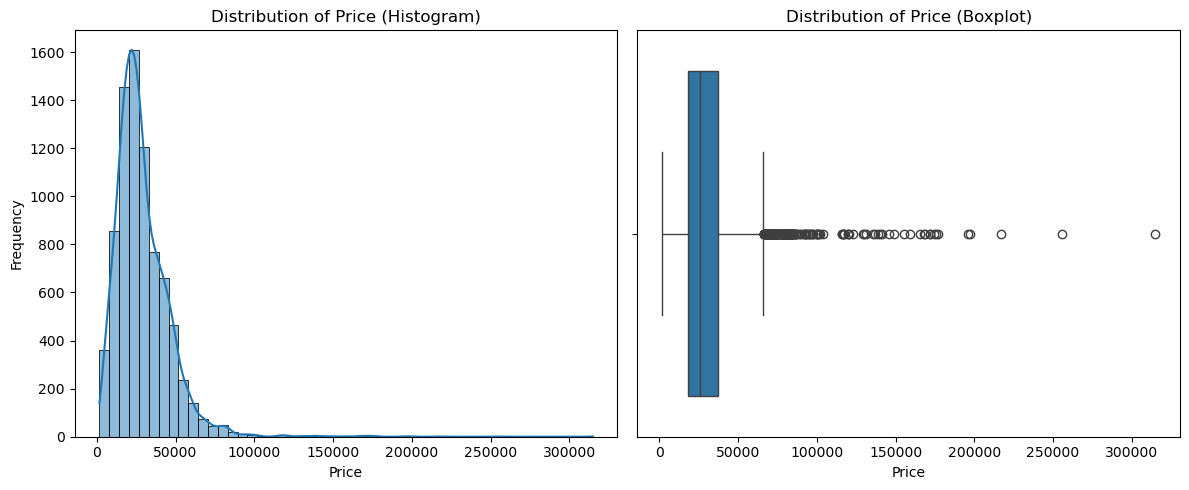

In [5]:
#plot histogram and boxplot of price side by side
plt.figure(figsize=(12, 5))

#Histogram
plt.subplot(1, 2, 1)
sns.histplot(train['price'], bins=50, kde=True)
plt.title('Distribution of Price (Histogram)')
plt.xlabel('Price')
plt.ylabel('Frequency')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=train['price'])
plt.title('Distribution of Price (Boxplot)')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

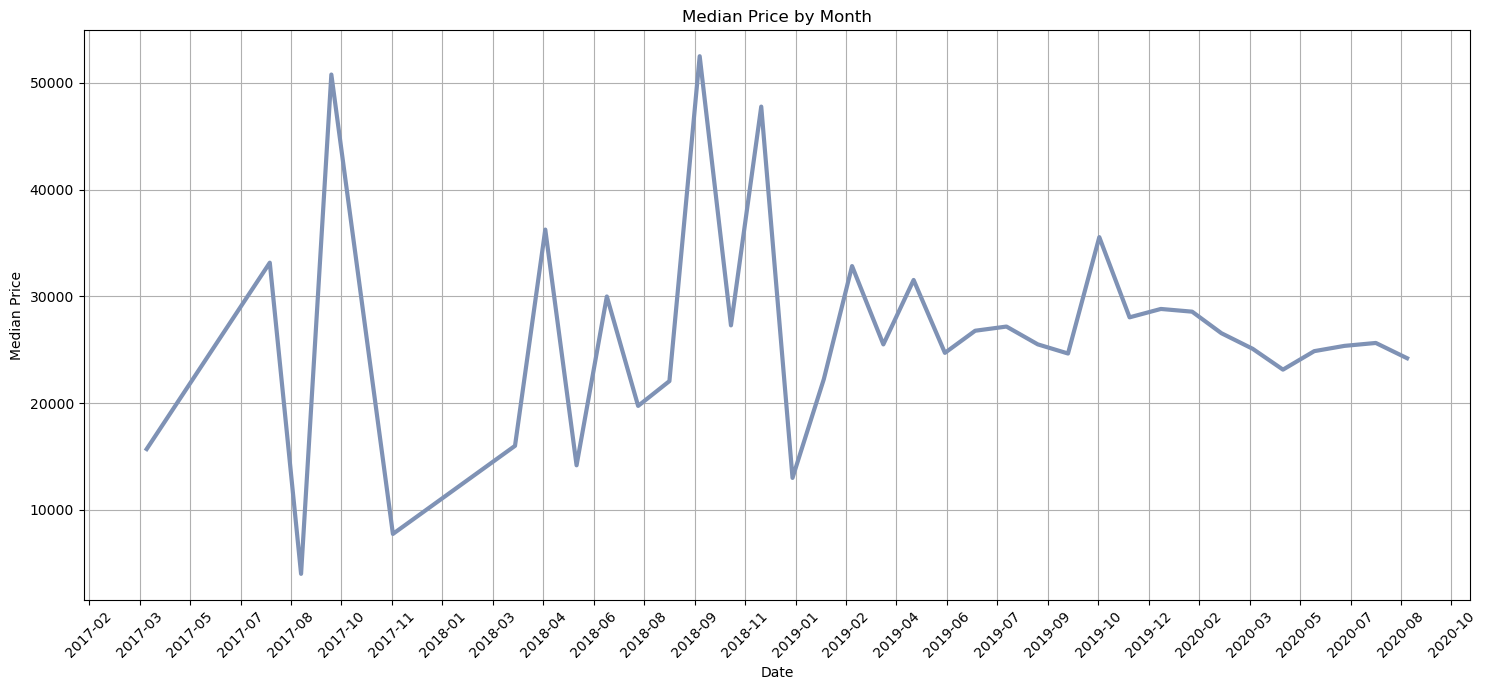

In [6]:
#Extract year and month from listed_date
train['listed_date'] = pd.to_datetime(train['listed_date'])
train['year_month'] = train['listed_date'].dt.to_period('M')

#Group by year_month and calculate the median price
median_price_by_month = train.groupby('year_month')['price'].median()

#Convert the Period index to datetime for plotting
median_price_by_month.index = median_price_by_month.index.to_timestamp()

#Plot the time series of median price
plt.figure(figsize=(15, 7))
plt.plot(median_price_by_month.index, median_price_by_month.values, linewidth=3, color='#7f92b5')
plt.title('Median Price by Month')
plt.xlabel('Date')
plt.ylabel('Median Price')
plt.grid(True)

#Add more xticks and format them as month-year
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(30))
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.tight_layout()
plt.show()

#drop the year_month column after ward
train = train.drop(columns=['year_month'])

The target variable `price` has several notable characteristics:
- Distribution: The majority of used cars are priced below the $75,000 mark. The histogram shows strong positive skewness (right-skewed). This means a peak in the frequency for cars with a price tag in the $20,000 - $50,000 range.

- There a outliers in this variable, as evidenced by the long tail of the histogram and the boxplot. This indicates that while most cars are in the budget to midrange bracket, there are some very high-priced cars. The presence of these outliers pull the average price higher than the median.

- Temporal trends: There does not seem to be a consistent temporal trend. The median price can peak in Fall but the hike is often followed by large dips in the following months. This can indicate high volatility especially in 2017 and 2018. In 2019 and 2020, the median price of used cars seem to be more consistent.

In summary, the used cars market is dominated by budget-friendly vehicles. However, the existence of cars beyond $100,000 price tag lead to skewness. This means that the median price could be more suitable to represent the typical car's value than the average.

#### Vehicle specifications and conditions

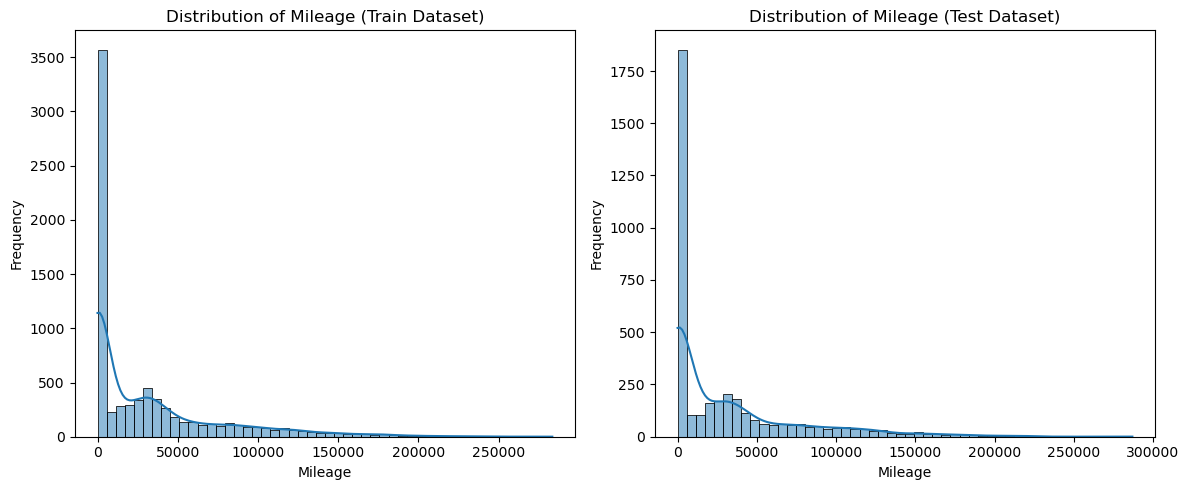

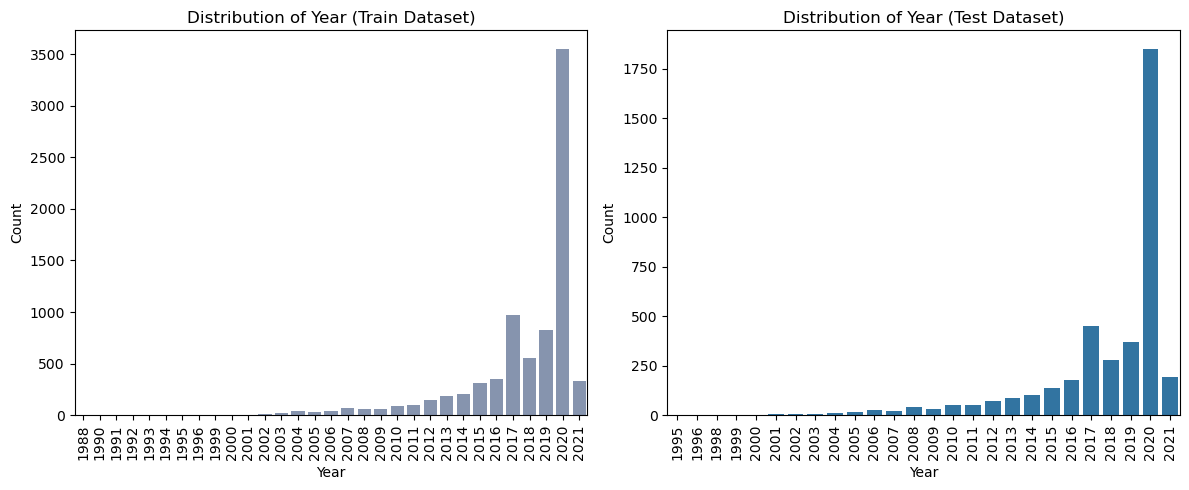

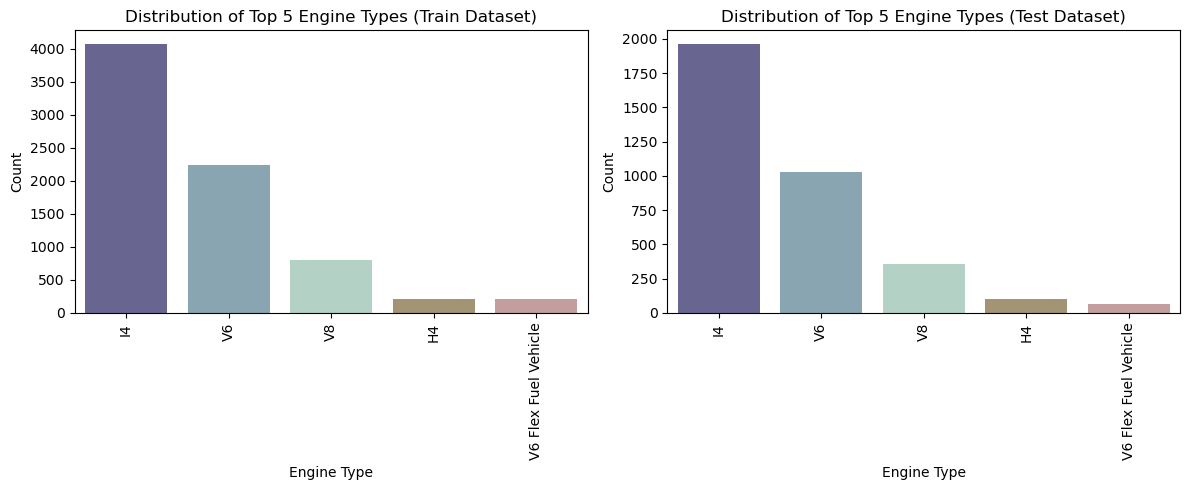

In [7]:
# Plot mileage of train and test side-by-side
plt.figure(figsize=(12, 5))

#Histogram for train mileage
plt.subplot(1, 2, 1)
sns.histplot(train['mileage'], bins=50, kde=True)
plt.title('Distribution of Mileage (Train Dataset)')
plt.xlabel('Mileage')
plt.ylabel('Frequency')

#Histogram for test mileage
plt.subplot(1, 2, 2)
sns.histplot(test['mileage'], bins=50, kde=True)
plt.title('Distribution of Mileage (Test Dataset)')
plt.xlabel('Mileage')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#Plot year of train and test side-by-side
plt.figure(figsize=(12, 5))

#Countplot for train year
plt.subplot(1, 2, 1)
sns.countplot(x=train['year'], color='#7f92b5')
plt.title('Distribution of Year (Train Dataset)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)

#Countplot for test year
plt.subplot(1, 2, 2)
sns.countplot(x=test['year'])
plt.title('Distribution of Year (Test Dataset)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#Visualize train and test engine_type distribution
plt.figure(figsize=(12, 5))

#Get top 5 engine types from the combined dataset for consistent ordering
all_engine_types = pd.concat([train['engine_type'], test['engine_type']]).value_counts().nlargest(5).index

#Countplot for train engine_type (showing top 5 and ordered)
plt.subplot(1, 2, 1)
sns.countplot(x=train['engine_type'], order=all_engine_types, palette=palette)
plt.title('Distribution of Top 5 Engine Types (Train Dataset)')
plt.xlabel('Engine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)

#Countplot for test engine_type (showing top 5 and ordered)
plt.subplot(1, 2, 2)
sns.countplot(x=test['engine_type'], order=all_engine_types, palette=palette)
plt.title('Distribution of Top 5 Engine Types (Test Dataset)')
plt.xlabel('Engine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

From the exploration of certain vehicle specifications and conditions attributes, we can see that:
- Both the train and test dataset are dominated by newer cars with smaller and more common engine types.
- First, the `mileage` variable is right-skewed, signifying that most vehicles accumulating less than 50,000 miles. The sharp drop as mileage increases demonstrates either (1) relatively new car or (2) sparingly-driven cars.
- Moreover, the `year` histogram is heavily left-skewed. This means that these cars are more recent models. There is also a significant increase of models released after 2015 with peaks around 2020-2021.
- Finally, the Inline arrangement with 4 cylinders is the most common engine type. This is typically designed for compact and mid-sized car with high fuel efficiency. V6 and V8 engines are for larger sedans, SUV, and trucks whose selling point is power. We also observe that the dataset is consistent across train and test dataset.

In summary, both the train and test dataset have modern and low-mileage cars with fuel-efficient engines. A typical car from this dataset would be a recently released model with little wear and tear due to low mileage. The train and test dataset are similar, suggesting fitness for model training and validating.

#### Manufacturers, Model and Aesthetics


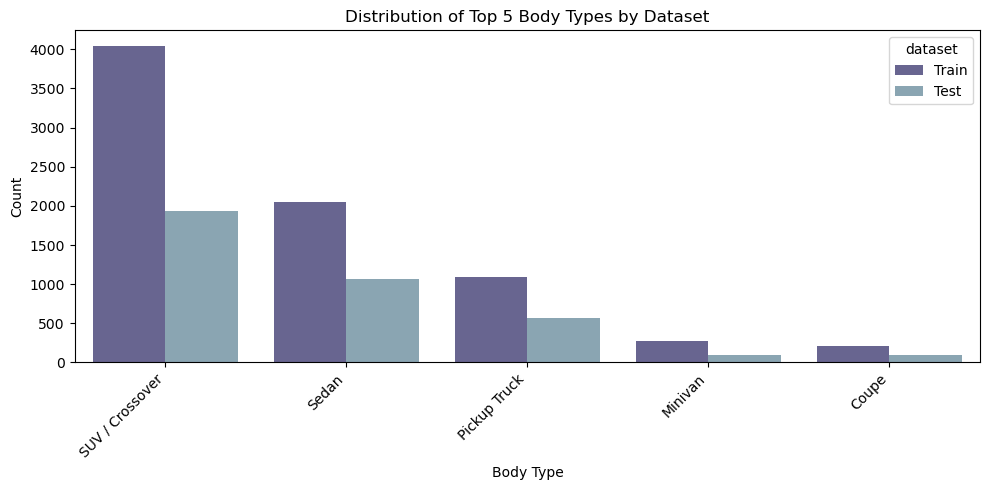

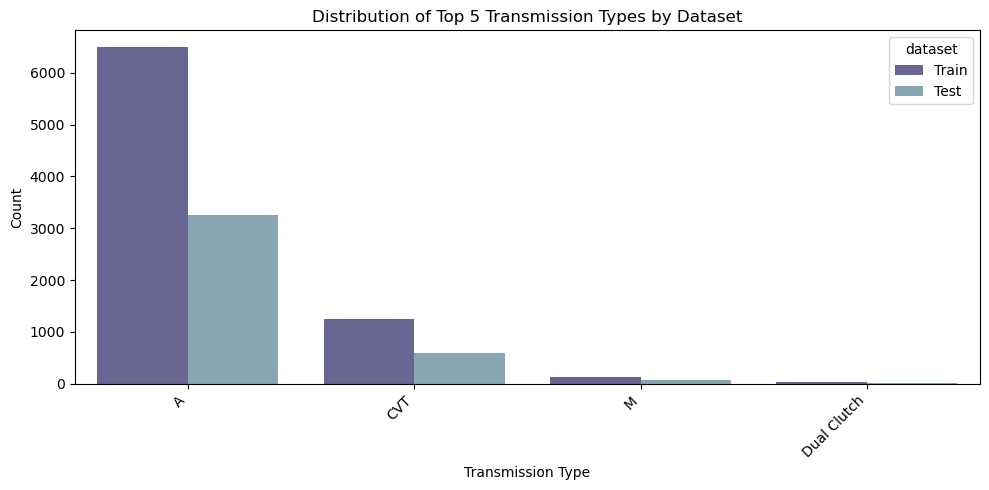

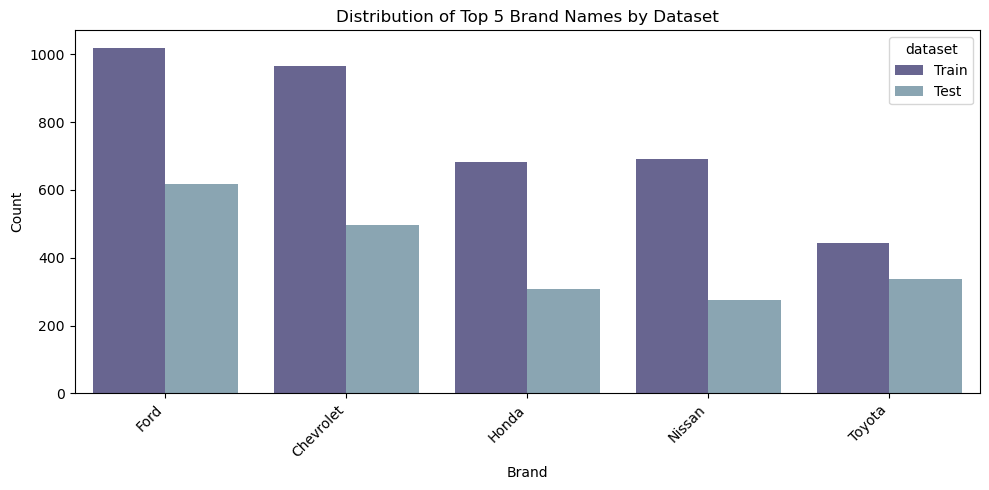

In [8]:
# Visualize train and test body_type distribution as a grouped bar chart
plt.figure(figsize=(10, 5))

# Combine train and test data for plotting
combined_body_types = pd.concat([train.assign(dataset='Train'),
                                 test.assign(dataset='Test')])

# Get top 5 body types from the combined dataset for consistent ordering
all_body_types = combined_body_types['body_type'].value_counts().nlargest(5).index

# Filter combined data to include only the top 5 body types
combined_body_types_top5 = combined_body_types[combined_body_types['body_type'].isin(all_body_types)]


# Create grouped bar chart
sns.countplot(data=combined_body_types_top5, x='body_type', hue='dataset', order=all_body_types, palette=palette)

plt.title('Distribution of Top 5 Body Types by Dataset')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Visualize train and test transmission distribution as a grouped bar chart
plt.figure(figsize=(10, 5))

# Combine train and test data for plotting
combined_transmission_types = pd.concat([train.assign(dataset='Train'),
                                         test.assign(dataset='Test')])

# Get top 5 transmission types from the combined dataset for consistent ordering
all_trans_types = combined_transmission_types['transmission'].value_counts().nlargest(5).index

# Filter combined data to include only the top 5 transmission types
combined_transmission_types_top5 = combined_transmission_types[combined_transmission_types['transmission'].isin(all_trans_types)]

# Create grouped bar chart
sns.countplot(data=combined_transmission_types_top5, x='transmission', hue='dataset', order=all_trans_types,  palette=palette)

plt.title('Distribution of Top 5 Transmission Types by Dataset')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Visualize train and test make_name distribution as a grouped bar chart
plt.figure(figsize=(10, 5))

# Combine train and test data for plotting
combined_make_names = pd.concat([train.assign(dataset='Train'),
                                 test.assign(dataset='Test')])

# Get top 5 make names from the combined dataset for consistent ordering
all_make_names = combined_make_names['make_name'].value_counts().nlargest(5).index

# Filter combined data to include only the top 5 make names
combined_make_names_top5 = combined_make_names[combined_make_names['make_name'].isin(all_make_names)]

# Create grouped bar chart
sns.countplot(data=combined_make_names_top5, x='make_name', hue='dataset', order=all_make_names, palette=palette)

plt.title('Distribution of Top 5 Brand Names by Dataset')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

There are varieties in the datasets in terms of car manufacturers, body types, and transmissions:
- The top five brand names are popular American car manufacturers such as Ford and Chevrolet. Car makers from Japan are also popular with Honda, Nissan, and Toyota brands. This distribution shows mainstream consumer prefers well-known and reliable automakers.

- Overall, consumers also prefer practicality over aesthetics. Evidently, the most prevalent body types such as Sedans, SUVs, or Pickup trucks are regarded as functional and efficient. Additionally, they are suitable for daily or family use.

- The prevalence of modern car models is also reflected in the domination of automatic transmissions, which becomes a standard feature now.

- For all attributes, the same pattern hold true in both the train and test dataset.

In summary, the used cars dataset is characterized by popular manufacturers such as Ford and Honda. Common preferences point towards functionality instead of aesthetics. Automatic transmission has become a standard feature in modern cars.

#### Listing information

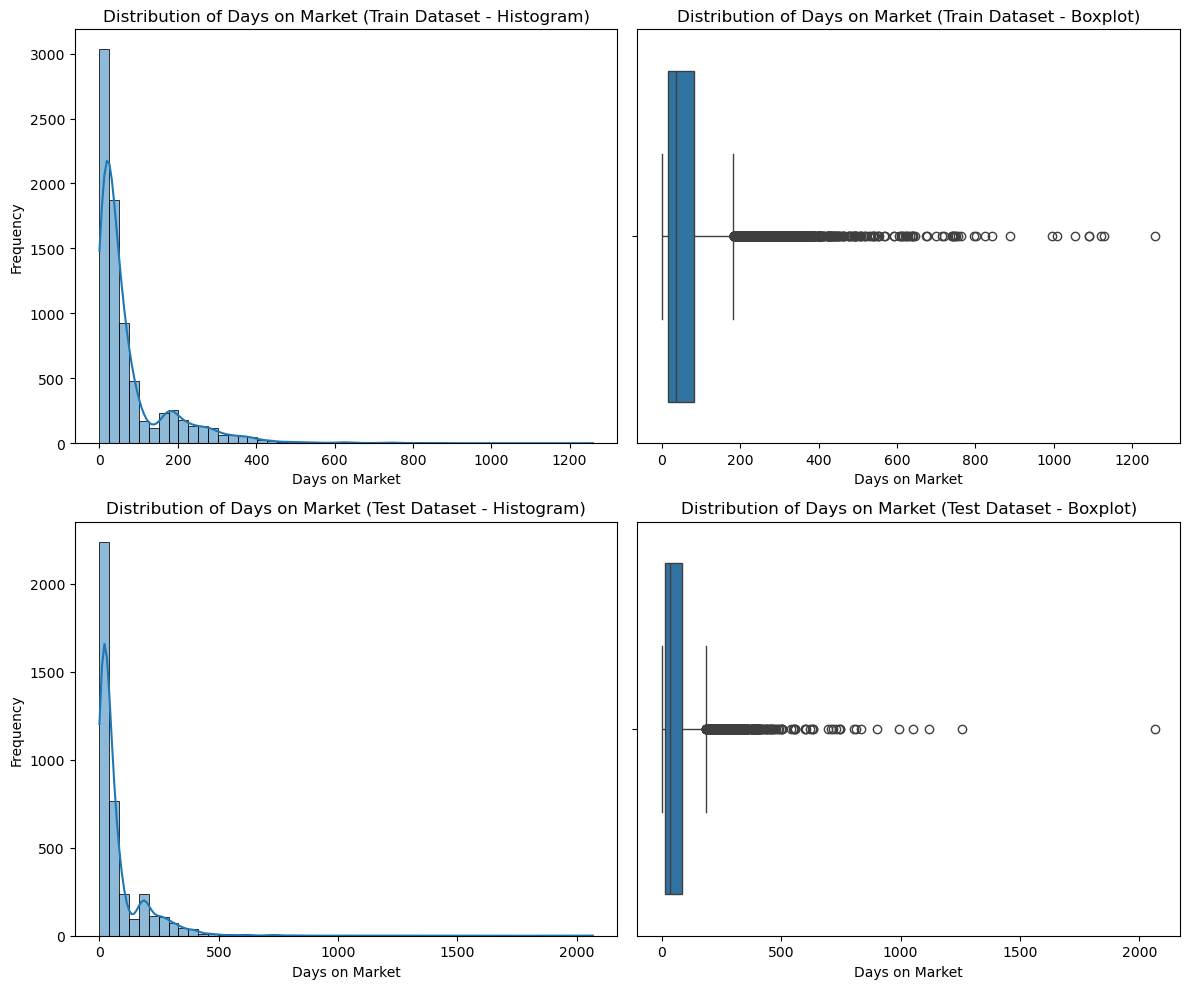

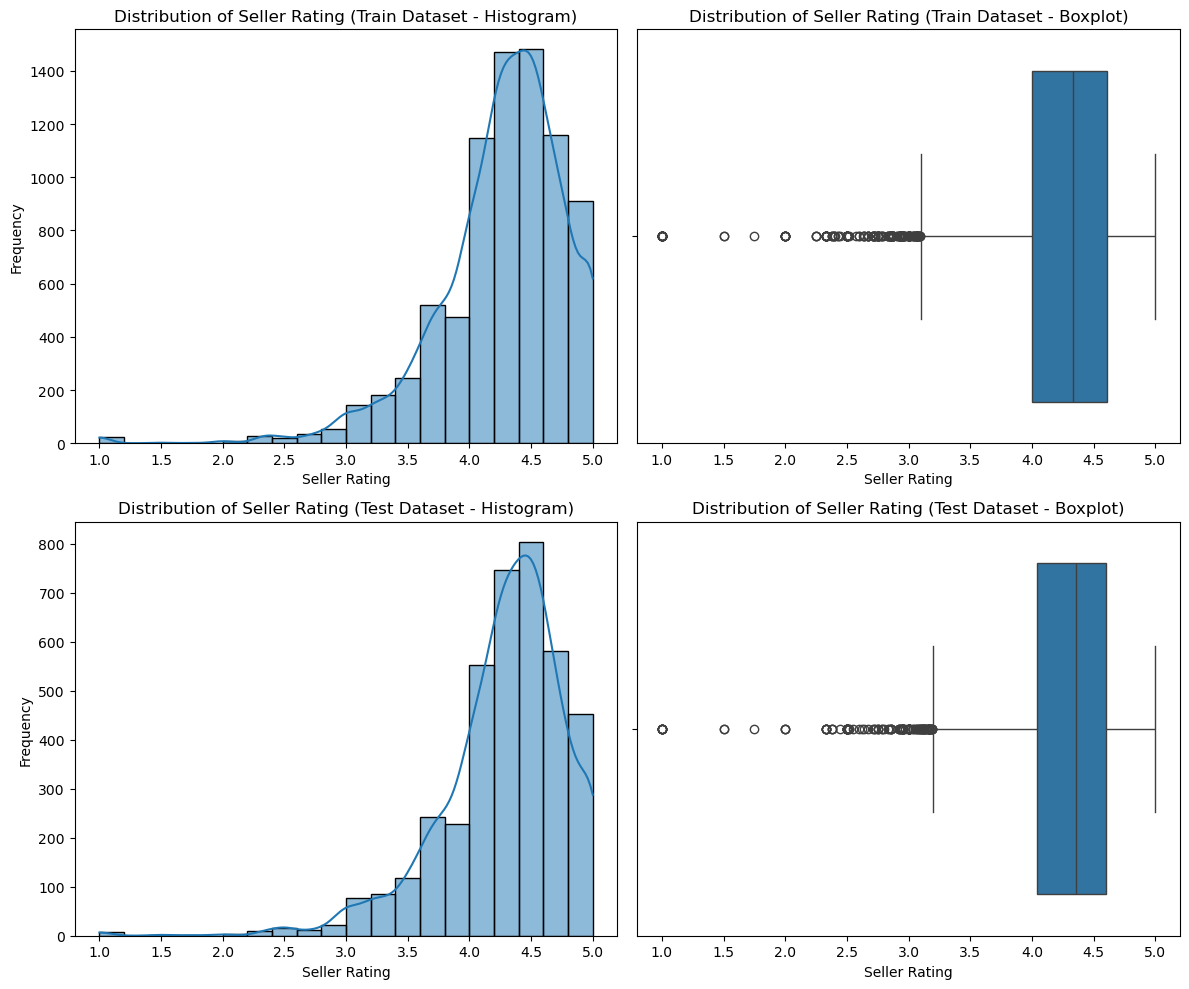

In [9]:
# Visualize train and test daysonmarket distribution with histogram and boxplot
plt.figure(figsize=(12, 10))

# Histogram for train daysonmarket
plt.subplot(2, 2, 1)
sns.histplot(train['daysonmarket'], bins=50, kde=True)
plt.title('Distribution of Days on Market (Train Dataset - Histogram)')
plt.xlabel('Days on Market')
plt.ylabel('Frequency')

# Boxplot for train daysonmarket
plt.subplot(2, 2, 2)
sns.boxplot(x=train['daysonmarket'])
plt.title('Distribution of Days on Market (Train Dataset - Boxplot)')
plt.xlabel('Days on Market')

# Histogram for test daysonmarket
plt.subplot(2, 2, 3)
sns.histplot(test['daysonmarket'], bins=50, kde=True)
plt.title('Distribution of Days on Market (Test Dataset - Histogram)')
plt.xlabel('Days on Market')
plt.ylabel('Frequency')

# Boxplot for test daysonmarket
plt.subplot(2, 2, 4)
sns.boxplot(x=test['daysonmarket'])
plt.title('Distribution of Days on Market (Test Dataset - Boxplot)')
plt.xlabel('Days on Market')

plt.tight_layout()
plt.show()


# Compare seller rating for train and test set with histogram and boxplot
plt.figure(figsize=(12, 10))

# Histogram for train seller_rating
plt.subplot(2, 2, 1)
sns.histplot(train['seller_rating'], bins=20, kde=True)
plt.title('Distribution of Seller Rating (Train Dataset - Histogram)')
plt.xlabel('Seller Rating')
plt.ylabel('Frequency')

# Boxplot for train seller_rating
plt.subplot(2, 2, 2)
sns.boxplot(x=train['seller_rating'])
plt.title('Distribution of Seller Rating (Train Dataset - Boxplot)')
plt.xlabel('Seller Rating')

# Histogram for test seller_rating
plt.subplot(2, 2, 3)
sns.histplot(test['seller_rating'], bins=20, kde=True)
plt.title('Distribution of Seller Rating (Test Dataset - Histogram)')
plt.xlabel('Seller Rating')
plt.ylabel('Frequency')

# Boxplot for test seller_rating
plt.subplot(2, 2, 4)
sns.boxplot(x=test['seller_rating'])
plt.title('Distribution of Seller Rating (Test Dataset - Boxplot)')
plt.xlabel('Seller Rating')

plt.tight_layout()
plt.show()


In [10]:
%%capture
pip install pgeocode

In [11]:
import pgeocode

def get_state_from_zip(df):
    zip_col = 'dealer_zip'
    country_code ='us'
    df[zip_col] = df[zip_col].astype(str).str.zfill(5)
    nomi = pgeocode.Nominatim(country_code)

    # Get unique ZIP codes
    unique_zips = df[zip_col].unique()

    # Query pgeocode for all unique zips
    geo = nomi.query_postal_code(unique_zips)

    # Create a mapping from zip code to state
    zip_to_state = dict(zip(geo['postal_code'], geo['state_code']))

    # Map the state codes to the DataFrame
    df['state'] = df[zip_col].map(zip_to_state)

    return df

train = get_state_from_zip(train)
test = get_state_from_zip(test)

def plot_state_listings_map(train_df, test_df):
    all_states = pd.concat([train_df['state'], test_df['state']]).dropna()

    # Get the count of listings per state
    state_counts = all_states.value_counts().reset_index()
    state_counts.columns = ['state', 'listing_count']

    # Create the choropleth map
    fig = px.choropleth(state_counts,
                        locations='state',
                        locationmode="USA-states",
                        color='listing_count',
                        scope="usa",
                        color_continuous_scale="YlGnBu",
                        title="Number of Listings per State")
    fig.show()

# Ensure the 'state' column exists (it's added in cell 7dad6159)
# Call the function to plot the map
plot_state_listings_map(train, test)

# Drop the 'state' column from the original dataframes after plotting
train = train.drop(columns=['state'], errors='ignore')
test = test.drop(columns=['state'], errors='ignore')


The listing data also reveals several patterns of the used cars dataset:
- We first look at days on the market or how long the vehicles have been listed on the website. This variable is right-skewed, meaning that most cars are sold quite quickly (within the first few weeks). However, the boxplot has numerous outliers. In other words, there are harder to sell cars, extending beyond the 6-month mark.
- Then, we look at seller ratings. This variable is left-skewed, showing most sellers have high ratings. The average and median ratings are around 4.2 - 4.3 range. This shows that the sellers are typically high-reputated. Similarly, we notice the outliers from the boxplot. These are sellers with low ratings and would be normally avoided by users.
- Finally, the market dynamic is characterized by dominance of listings from Texas, California, Florida. These states are the most active, suggesting higher demand and supply.


In summary, most listings tend to have efficient sales process. These used cars are typically sold relatively fast by reputable sellers. However, there are many cars that are harder to sell, either because its sellers have lower ratings or they are in less active markets.

---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

- You must clearly explain all your answers in both the Markdown file and your presentation.

**Total Marks: 8**

Student in charge of this task: `Luong Phuong Anh Pham`

### Question 1: Clean numerical features

**Task 2, Question 1**: Clean **all** numerical features so that they can be used in training algorithms. For instance, `back_legroom` feature is in object format containing both numerical values and text. Extract numerical values (or equivalently eliminate the text) so that the numerical values can be used as a regular feature.  
(2 marks)

In [12]:
## Task 2, Question 1 Code Here

import datetime as dt
from sklearn.preprocessing import OneHotEncoder

def clean_numeric(df):
    num_features= ["back_legroom", "front_legroom", "height", "wheelbase", "width", "maximum_seating"]
    for column in num_features:
        df[column]= df[column].astype(str).str.replace(r"(in|--|—|–|seats)", "", regex=True)
        df[column]= df[column].str.strip()
        df[column]= pd.to_numeric(df[column], errors="coerce")
        df[column]= df[column].replace("", np.nan)

    return df

df_train= clean_numeric(train)
df_test= clean_numeric(test)

- Purpose:

From our categorisation of data type, several dimension and seating columns contain measurement units and special characters. This prevents Python from recognizing them as numeric data types, requiring text removal/preprocessing before numeric conversion.

- Implementation:

The function `task2_question1()` systematically cleans and converts specific columns to ensure they are properly formatted as numeric data. It works by iterating through each affected column and first removing unwanted text patterns such as “in”, “seats” and special dash characters using a regular expression. After these non-numeric elements are stripped, the function removes any extra whitespace to tidy up the string values. It then converts the cleaned text into numeric format using pd.to_numeric(). Finally, empty strings are replaced with NaN to maintain consistency in representing missing data. Through these steps, the function ensures the columns are stored as numeric (float64) types, making them suitable for statistical analysis, visualization, and machine learning algorithms.

- Reason: 

The columns `back_legroom`, `front_legroom`, `height`, `wheelbase`, `width`, and `maximum_seating` store numeric measurements but include text suffixes like "in" (inches), "seats", and placeholder characters ("--", "—", "–"). These non-numeric elements cause Python to interpret entire columns as object (string) type rather than numeric. Thus, the cleaning process removes these text elements using regex pattern matching, strips whitespace, and converts values to numeric format. Values that cannot be converted are marked as `np.nan` for later imputation.

### Question 2: Create new features

**Task 2, Question 2** Create at least 4 new features from existing features which contain multiple items of information.   
(1 marks)

In [13]:
## Task 2, Question 2 Code Here
def task2_q2(df):
    # Split power into power_hp and power_rpm
    df[['power_hp', 'power_rpm']] = df["power"].str.extract(r'(\d+)\s*hp\s*@\s*([\d,]+)\s*RPM')
    df['power_hp'] = pd.to_numeric(df['power_hp'], errors='coerce')
    df['power_rpm'] = pd.to_numeric(df['power_rpm'].str.replace(',', ''), errors='coerce')

    # Split torque into torque_lbft and torque_rpm
    df[['torque_lbft', 'torque_rpm']]= df["torque"].str.extract(r'(\d+)\s*lb-ft\s*@\s*([\d,]+)\s*RPM')
    df['torque_lbft'] = pd.to_numeric(df['torque_lbft'], errors='coerce')
    df['torque_rpm'] = pd.to_numeric(df['torque_rpm'].str.replace(',', ''), errors='coerce')

    # Split engine_type into cylinders_num and cylarr_type
    df[['cylarr_type','cylinders_num']] = df["engine_type"].str.extract(r'([A-Za-z])(\d+)')
    df['cylinders_num'] = pd.to_numeric(df['cylinders_num'],errors='coerce', downcast='integer')

    # Split transmission display to gear_num and trans_type
    df['gear_num'] = df['transmission_display'].str.extract(r'(\d+)?[- ]*[A-Za-z].*')
    df.loc[df['transmission_display'].notna() & df['gear_num'].isna(), 'gear_num'] = 1
    df['gear_num'] = df['gear_num'].astype(float).astype('Int64')

    # Extra handling before imputing
    # Create Age
    df['age'] = dt.datetime.now().year - df['year']

    # Split listed_date into listed_date, listed_month, listed_year
    df['listed_date']= pd.to_datetime(df['listed_date'], errors='coerce')
    df['listed_year'] = df['listed_date'].dt.year
    df['listed_month'] = df['listed_date'].dt.month
    df['listed_date'] = df['listed_date'].dt.day

    # Drop columns
    df = df.drop(['power','torque','engine_type','transmission_display'], axis=1)

    return df

df_train= task2_q2(df_train)
df_test= task2_q2(df_test)

In [14]:
def target_encoding(df_train, df_test):

    brand_price_map = df_train.groupby('make_name')['price'].mean().to_dict()
    df_train['brand_avg_price'] = df_train['make_name'].map(brand_price_map)
    df_test['brand_avg_price'] = df_test['make_name'].map(brand_price_map)

    return df_train, df_test

df_train, df_test = target_encoding(df_train, df_test)

- Purpose:

Multiple columns combine several pieces of information into single text strings and extracting these into separate numeric features contributes to later training process and improves model performance.

- Implementation:

There are 11 new columns are created by decomposing compoud columns.

In details, the following columns are created after spliting from the columns: `power`, `torque`, `engine_type`, `transmission_display`

1. **Power features** (`power_hp`, `power_rpm`): Extract horsepower and RPM from "270 hp @ 5,600 RPM"

2. **Torque features** (`torque_lbft`, `torque_rpm`): Extract torque force and RPM from "269 lb-ft @ 5,200 RPM"

3. **Engine configuration** (`cylarr_type`, `cylinders_num`): Split "V6" into cylinder arrangement type ("V") and count (6)

4. **Transmission details** (`gear_num`): Extract number of gears from "9-Speed Automatic". The transmission type text is skipped because it duplicates information in the `transmission` column.

After extraction, the original redundant columns (`power`, `torque`, `engine_type`, and `transmission_display`) are dropped to reduce dimensionality.

- Reasoning:

Machine learning models perform better with granular numeric features than with compound text strings. Separating power into horsepower and RPM allows the model to learn different relationships for each component.

- Additional implementation:

1. **Vehicle age (age)**: Calculate years since first manufactured (current year - year)
2. **Temporal features** (listed_year, listed_month, listed_date): Decompose listing timestamp as guided by the seasonality effect in later step to improve the model's performance.
3. **Brand pricing signal** (`brand_avg_price`)(separate function): Target encoding using mean price per manufacturer (`make_name`).

- Reasoning for additional implementation:

Firstly, the main implementation helps separate coumpound text into numeric features, which allows model to learn in later steps.

Seconly, the vehicle age and temporal features provides meaningful context for training process. Besides, they are created here to ensure that the missing values will be imputed if needed.

Finally, the average price of each brand captures manufacturer-level pricing trends to help reduce model error. `make_name` represents different car manufacturers. From the earlier EDA, lower-priced cars tend to dominate the dataset, and the price could be linked to the manufacturers. In Task 4, Question 2, this categorical feature needs to be encoded into the top five most common brands and grouped as “others” for the rest. As a result, much of the original information in `make_name` could be lost. To preserve some of this information, a new feature called brand_avg_price is created, capturing the average price associated with each `make_name`. This approach is known as target encoding in feature engineering. The column is generated at this stage so that any missing values can be imputed later in Task 2, Question 3.

### Question 3: Impute missing values

**Task 2, Question 3**: Impute the missing values for all features in both the training and test datasets.   
(2 marks)

In [15]:
# Check the missing values columns
def replace_missing_values(df):
    missing_patterns = [
        'nan', 'na', 'n/a', 'NAN', 'NA', 'N/A',
        'unknown', 'Unknown',
        'none', 'None', 'NONE',
        '--', '—', 'null', 'NULL', 'Null',
        '', ' '
    ]
    for col in df.columns:
        df[col] = df[col].replace(missing_patterns, np.nan)

    return df

df_train = replace_missing_values(df_train)
df_test = replace_missing_values(df_test)

df_train_null = df_train.isna().sum()
df_test_null = df_test.isnull().sum()
df_train_null_percentage = df_train_null / len(df_train) * 100
df_test_null_percentage = df_test_null / len(df_test) * 100
df_train_test_null = pd.DataFrame({
    'train': df_train_null,
    'test': df_test_null,
    'train_pct': df_train_null_percentage,
    'test_pct': df_test_null_percentage
})
df_train_test_null[df_train_test_null.sum(axis=1) > 0]

,train,test,train_pct,test_pct
back_legroom,160,138.00,2.00,3.45
brand_avg_price,0,8.00,0.00,0.20
city_fuel_economy,0,455.00,0.00,11.38
cylarr_type,0,72.00,0.00,1.80
cylinders_num,0,72.00,0.00,1.80
engine_displacement,0,40.00,0.00,1.00
exterior_color,117,64.00,1.46,1.60
franchise_dealer,102,46.00,1.27,1.15
front_legroom,52,63.00,0.65,1.57
fuel_type,0,54.00,0.00,1.35


In [16]:
## Task 2, Question 3 Code Here
class Imputer():
    def __init__(self):
        self.global_modes = {}
        self.global_means = {}
        self.global_medians = {}

    def global_values(self, df):
        categorial_columns = [
            'listing_color', 'interior_color', 'exterior_color', 'franchise_dealer',
            'transmission', 'wheel_system', 'fuel_type', 'cylarr_type'
        ]

        for c in categorial_columns:
            m = df[c].dropna().mode()
            self.global_modes[c] = m.iloc[0] if not m.empty else None

        numeric_mean_columns = [
            "horsepower","cylinders_num","city_fuel_economy","highway_fuel_economy",
            "power_hp","power_rpm","torque_rpm","torque_lbft","engine_displacement",
            "height","width","wheelbase","back_legroom","front_legroom",
            "maximum_seating"
        ]

        for c in numeric_mean_columns:
            self.global_means[c] = df[c].mean()

        numeric_median_columns = ["mileage","savings_amount","gear_num","seller_rating","brand_avg_price"]
        for c in numeric_median_columns:
            self.global_medians[c] = df[c].median()

        return self

    def transform(self, df):
        def fill_mode_with_fallback(series, group_by_cols_list, global_val):
            for group_by_cols in group_by_cols_list:
                if all(col in df.columns for col in group_by_cols):
                    filled = df.groupby(group_by_cols)[series.name].transform(
                        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else pd.NA)
                    )
                    series = series.fillna(filled)
                    if series.isna().sum() == 0:
                        return series
            return series.fillna(global_val)

        def fill_mean_with_fallback(series, group_by_cols_list, global_val):
            for group_by_cols in group_by_cols_list:
                if all(col in df.columns for col in group_by_cols):
                    filled = df.groupby(group_by_cols)[series.name].transform(
                        lambda x: x.fillna(x.mean() if pd.notna(x.mean()) else pd.NA)
                    )
                    series = series.fillna(filled)
                    if series.isna().sum() == 0:
                        return series
            return series.fillna(global_val)

        def fill_median_with_fallback(series, group_by_cols_list, global_val):
            for group_by_cols in group_by_cols_list:
                if all(col in df.columns for col in group_by_cols):
                    filled = df.groupby(group_by_cols)[series.name].transform(
                        lambda x: x.fillna(x.median() if pd.notna(x.median()) else pd.NA)
                    )
                    series = series.fillna(filled)
                    if series.isna().sum() == 0:
                        return series
            return series.fillna(global_val)

        int_col = ['cylinders_num','gear_num','maximum_seating']
        for c in int_col:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype(float)

        # 1. Categorical features with fallback chains
        appearance_fallbacks = [
            ['make_name', 'model_name', 'year'],
            ['make_name', 'model_name'],
            ['make_name'],
            ['body_type']
        ]
        for c in ['listing_color', 'interior_color', 'exterior_color']:
            if c in df.columns and c in self.global_modes:
                df[c] = fill_mode_with_fallback(df[c], appearance_fallbacks, self.global_modes[c])

        if 'franchise_dealer' in df.columns and 'franchise_dealer' in self.global_modes:
            dealer_fallbacks = [['dealer_zip'], ['city']]
            df['franchise_dealer'] = fill_mode_with_fallback(df['franchise_dealer'], dealer_fallbacks,
                                                             self.global_modes['franchise_dealer'])

        mechanical_fallbacks = [
            ['make_name', 'model_name', 'cylarr_type', 'year'],
            ['make_name', 'model_name', 'year'],
            ['make_name', 'cylarr_type'],
            ['make_name']
        ]
        for c in ['transmission', 'wheel_system', 'fuel_type', 'cylarr_type']:
            if c in df.columns and c in self.global_modes:
                df[c] = fill_mode_with_fallback(df[c], mechanical_fallbacks, self.global_modes[c])

        # Geographic feature
        if 'latitude' in df.columns:
            geo_fallbacks = [['city'], ['dealer_zip']]
            df['latitude'] = fill_mean_with_fallback(df['latitude'], geo_fallbacks,
                                                     df['latitude'].mean() if 'latitude' not in self.global_means
                                                     else self.global_means.get('latitude', df['latitude'].mean()))

        # 2. Numeric mean features with fallback
        numeric_mean_with_fallbacks = [
            ['make_name', 'model_name', 'cylarr_type', 'year'],
            ['make_name', 'model_name', 'year'],
            ['make_name', 'cylarr_type'],
            ['make_name']]

        for c in ["horsepower", "cylinders_num", "city_fuel_economy", "highway_fuel_economy",
                  "power_hp", "power_rpm", "torque_rpm", "engine_displacement"]:
            if c in df.columns and c in self.global_means:
                df[c] = fill_mean_with_fallback(df[c], numeric_mean_with_fallbacks, self.global_means[c])

        size_fallbacks = [['body_type'], ['make_name']]
        for c in ["height", "width", "wheelbase", "back_legroom", "front_legroom", "maximum_seating"]:
            if c in df.columns and c in self.global_means:
                df[c] = fill_mean_with_fallback(df[c], size_fallbacks, self.global_means[c])

        # 3. Numeric median features with fallback
        if "mileage" in df.columns and "mileage" in self.global_medians:
            numeric_median_with_fallback = [
                ['year', 'city', 'is_new'],
                ['year', 'is_new'],
                ['year']
            ]
            df["mileage"] = fill_median_with_fallback(df["mileage"], numeric_median_with_fallback,
                                                      self.global_medians["mileage"])

        for c in ["savings_amount", "gear_num"]:
            if c in df.columns and c in self.global_medians:
                savings_fallbacks = [
                    ['make_name', 'model_name', 'year'],
                    ['make_name', 'year'],
                    ['make_name']
                ]
                df[c] = fill_median_with_fallback(df[c], savings_fallbacks, self.global_medians[c])

        if "seller_rating" in df.columns and "seller_rating" in self.global_medians:
            rating_fallbacks = [['dealer_zip'], ['city']]
            df["seller_rating"] = fill_median_with_fallback(df["seller_rating"], rating_fallbacks,
                                                           self.global_medians["seller_rating"])

        if "brand_avg_price" in df.columns and "brand_avg_price" in self.global_medians:
            brand_fallbacks = [['make_name']]
            df["brand_avg_price"] = fill_median_with_fallback(df["brand_avg_price"], brand_fallbacks,
                                                              self.global_medians["brand_avg_price"])

        for c, v in self.global_means.items():
            if c in df.columns:
                df[c] = df[c].fillna(v)
        for c, v in self.global_medians.items():
            if c in df.columns:
                df[c] = df[c].fillna(v)
        for c, v in self.global_modes.items():
            if c in df.columns:
                df[c] = df[c].fillna(v)

        for c in int_col:
            if c in df.columns:
                df[c] = df[c].round().astype('Int64')

        return df

imp = Imputer()
imp.global_values(df_train)
df_train = imp.transform(df_train)
df_test  = imp.transform(df_test)

In [17]:
# Recheck (reuse the code in question 1)
df_train_null = df_train.isna().sum()
df_test_null = df_test.isnull().sum()
df_train_null_percentage = df_train_null / len(df_train) * 100
df_test_null_percentage = df_test_null / len(df_test) * 100
df_train_test_null = pd.DataFrame({
    'train': df_train_null,
    'test': df_test_null,
    'train_pct': df_train_null_percentage,
    'test_pct': df_test_null_percentage
})
df_train_test_null[df_train_test_null.sum(axis=1) > 0]

,train,test,train_pct,test_pct


This task follows the process of checking the missing values columns, imputing, and rechecking the imputing results.

- Purpose:

   Missing values are imputed using grouped statistics (mode/mean/median within logical categories) with multiple fallback chains to ensure that missing values are imputed. The fallback chains means if the imputed columns with group of A,B,C contain null mode/mean/median, then the larger group by A,B will be used. With the same logics, until there is no group contain valid mode/mean/median. Then, the global mode/mean/median of that column is used to imput the missing values.


- Implementation:

  - **Calculate the global mean/mode/median**:
  This stage only learns from `train` data instead of combining the training and testing set to avoid data leakage. In this stage,
     - Calculates global modes for categorical features: `listing_color`,`interior_color`, `exterior_color`, `franchise_dealer`,`transmission`, `wheel_system`, `fuel_type`,`cylarr_type`
     - Calculates global means for performance/dimension features, including `horsepower`,`cylinders_num`,`city_fuel_economy`,`highway_fuel_economy`, `power_hp`, `power_rpm`, `torque_rpm`,`torque_lbft`,`engine_displacement`, `height`, `width`,`wheelbase`, `back_legroom`,`front_legroom`,`maximum_seating`

     - Calculates global medians for skewed features: `mileage`, `savings_amount`, `seller_rating`

  - **Transformation**:
  Uses fallback chains where missing values are filled progressively:

| **Feature Group**                 | **Columns**                                                                                                                              | **Fallback Order**                                                                                           | **Statistic Used** |
| --------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | ------------------ |
| **Appearance features**           | `listing_color`, `interior_color`, `exterior_color`                                                                                      | `[make_name, model_name, year] → [make_name, model_name] → [make_name] → [body_type] → global values`                                 | Mode               |
| **Dealer-related**                | `franchise_dealer`                                                                                                                       | `[dealer_zip] → [city] → global values`                                                                                               | Mode               |
| **Mechanical features**           | `transmission`, `wheel_system`, `fuel_type`, `cylarr_type`                                                                               | `[make_name, model_name, cylarr_type, year] → [make_name, model_name, year] → [make_name, cylarr_type] → [make_name] → global values` | Mode               |
| **Performance / engine features** | `horsepower`, `cylinders_num`, `city_fuel_economy`, `highway_fuel_economy`, `power_hp`, `power_rpm`, `torque_rpm`, `engine_displacement` | `[make_name, model_name, cylarr_type, year] → [make_name, model_name, year] → [make_name, cylarr_type] → [make_name] → global values` | Mean               |
| **Dimension features**            | `height`, `width`, `wheelbase`, `back_legroom`, `front_legroom`, `maximum_seating`                                                       | `[body_type] → [make_name] → global values`                                                                                           | Mean               |
| **Geographic feature**            | `latitude`                                                                                                                               | `[city] → [dealer_zip] → global values`                                                                                               | Mean               |
| **Usage / condition feature**     | `mileage`                                                                                                                                | `[year, city, is_new] → [year, is_new] → [year] → global values`                                                                      | Median             |
| **Savings-related features**      | `savings_amount`, `gear_num`                                                                                                             | `[make_name, model_name, year] → [make_name, year] → [make_name] → global values`                                                     | Median             |
| **Seller-related feature**        | `seller_rating`                                                                                                                          | `[dealer_zip] → [city] → global values`                                                                                               | Median             |
| **Brand-level pricing**           | `brand_avg_price`                                                                                                                        | `[make_name] → global values`                                                                                                         | Median             |


- Additional handling:

For the discrete numeric columns `cylinders_num`, `gear_num`, and `maximum_seating`, the mean values will be rounded to preserve the discrete nature of these features.

- Reasoning:

Simple global imputation (filling all missing values with overall mean/mode) ignores important patterns and introduces bias. A 2020 luxury sedan and a 2010 economy truck should not receive the same imputed mileage value. Grouped imputation respects the data's natural structure by filling missing values using similar vehicles' statistics. The fallback chain handles groups with null.

### Question 4: Encode categorical variables

**Task 2, Question 4**: Encode all categorical variables appropriately as discussed in class.

- Where multiple values are given for an observation encode the observation as 'other'.
- Where a categorical feature contains more than 5 unique values, map the features into 5 most frequent values + 'other' and then encode appropriately. For instance, if appropriate, you could all map colours into {red, yellow, green, blue, purple, other} and then encode.
(2 marks)

In [18]:
## Task 2, Question 4 Code Here
def encode_boolean(df):
    for col in ['franchise_dealer','is_new']:
        df[col] = (df[col].astype(str).str.strip().str.lower().map({'true': True, 'false': False, '1': True, '0': False}))
        df[col] = df[col].astype(int)
    return df
df_train = encode_boolean(df_train)
df_test = encode_boolean(df_test)

def encode_nominal_with_rules(df_train, df_test):
    categorical_cols = df_train.select_dtypes(include='object').columns.tolist()
    exclude_cols = ["vin", "dealer_zip", "city", "exterior_color"]
    categorical_cols = [c for c in categorical_cols if c not in exclude_cols]

    top5_dict = {}
    for col in categorical_cols:
        top5_dict[col] = df_train[col].value_counts().head(5).index.tolist()

    def clean_values(df, top5_dict):
        for col, top_vals in top5_dict.items():
            df[col] = df[col].astype(str).apply(
                lambda x: 'other'
                if (',' in x or '/' in x or ';' in x or x not in top_vals)
                else x
            )
        return df

    df_train = clean_values(df_train.copy(), top5_dict)
    df_test = clean_values(df_test.copy(), top5_dict)

    encoder = OneHotEncoder(drop='first',sparse_output=False, handle_unknown='ignore')
    encoder.fit(pd.concat([df_train[categorical_cols], df_test[categorical_cols]], axis=0))

    train_encoded = pd.DataFrame(
        encoder.transform(df_train[categorical_cols]),
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df_train.index
    )
    test_encoded = pd.DataFrame(
        encoder.transform(df_test[categorical_cols]),
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df_test.index
    )

    df_train = pd.concat([df_train.drop(columns=categorical_cols), train_encoded], axis=1)
    df_test = pd.concat([df_test.drop(columns=categorical_cols), test_encoded], axis=1)

    drop_cols = ["dealer_zip","city", "exterior_color"]
    df_train.drop(columns=drop_cols,inplace=True)
    df_test.drop(columns=drop_cols, inplace=True)

    missing_cols = set(df_train.columns) - set(df_test.columns)
    for col in missing_cols:
        df_test[col] = 0
    df_test = df_test[df_train.columns] # This step is ensure the columns are consistent across two dataset, but it will create redundant "price" in df_test, we will drop "price" in test when making predictions

    return df_train, df_test

df_train, df_test = encode_nominal_with_rules(df_train, df_test)

- Purpose:

This code prepares categorical and boolean data for machine learning by cleaning, simplifying, and encoding them into numeric form with OneHotEncoding

- Implementation:

**1. Boolean Encoding (encode_boolean)**

  The function converts the columns `franchise_dealer` and `is_new` into integers:
   - Converts values like "True", "true", "1" → 1
   - Converts values like "False", "false", "0" → 0
  This ensures both `train` (df_train) and `test` (df_test) data have consistent binary (0/1) representation.

**2. Nominal Encoding (encode_nominal_with_rules)**
  This function handles categorical (string/object) features in three main steps:

   - Step 1: Select and filter categorical columns
     - Finds all object-type columns.
     - Excludes high-cardinality identifiers (`vin`, `dealer_zip`, `city`, `exterior_color`) that would create too many unique dummy variables.

   - Step 2: Simplify categories
     - For each categorical column, find the top 5 most frequent values in the training data.
     - Replace all other or messy entries (values containing ,, /, or ;, or not in top 5) with "other".

   - Step 3: One-Hot Encode
     - Uses OneHotEncoder to turn categories into binary (0/1) columns.
     - drop='first' avoids multicollinearity (dummy variable trap)
     - handle_unknown='ignore' prevents errors from unseen test values.

The encoder is performed on both train and test data to later use in machine learning.

**3. Final Adjustments**
  - Drops dealer_zip, city, and exterior_color to avoid unnecessary complexity.
  - Ensures df_test has the same columns as df_train, adding any missing columns filled with 0.
  - The step of column alignment is to ensure the columns are consistent across two dataset, but it will create redundant `price` in df_test, we will drop `price` in test when making predictions.

### Question 5: Perform additional preprocessing

**Task 2, Question 5**: Perform any additional data preparation steps you consider necessary before building your predictive models, and clearly explain each action you take.  
(1 mark)

In [19]:
df_train["seller_rating"].describe()

count   8,000.00
mean        4.26
std         0.52
min         1.00
25%         4.00
50%         4.33
75%         4.60
max         5.00
Name: seller_rating, dtype: float64

In [20]:
## Task 2, Question 5 Code Here
def define_outliers(df):
    features_to_process = {'mileage': 0.998,'daysonmarket': 0.998}

    outlier_result= {}

    for feature, quantile in features_to_process.items():
        if feature in df.columns:
            upper_threshold = df[feature].quantile(quantile)
            median_value = df[feature].median()

            outlier_result[feature] = {'upper_threshold': upper_threshold,'median': median_value}

    return outlier_result

def outliers_handler(outliers, df):
    df = df.copy()

    for feature, params in outliers.items():
        if feature in df.columns:
            df.loc[df[feature] > params['upper_threshold'], feature] = params['median']

    df['seller_rating'] = df['seller_rating'].clip(lower=0, upper=5)
    return df

outliers = define_outliers(df_train)
df_train = outliers_handler(outliers, df_train)
df_test = outliers_handler(outliers, df_test)



def new_features(df):
    # Feature transform
    df['log_mileage'] = np.log1p(df['mileage'])
    df['age_cubed'] = df['age'] ** 3

    # SEASON
    df['is_winter_listing'] = df['listed_month'].isin([10, 11, 12]).astype(int)
    df['is_summer_listing'] = df['listed_month'].isin([4, 5, 6]).astype(int)
    df['is_spring_listing'] = df['listed_month'].isin([1, 2, 3]).astype(int)
    df['is_fall_listing'] = df['listed_month'].isin([7, 8, 9]).astype(int)

    # DEPRECATION 
    df['depreciation_rate'] = (df['year'] - df['mileage'] / 12000) / df['age'].replace(0, 1) 
    df['value_per_hp'] = df['horsepower'] / df['engine_displacement'].replace(0, 1)
    
    
    # PERFORMANCE 
    df['power_to_weight'] = df['horsepower'] / df['maximum_seating'] 
    df['torque_hp_ratio'] = df['torque_lbft'] / df['power_hp'].replace(0, 1)
    df['fuel_efficiency_avg'] = (df['city_fuel_economy'] + df['highway_fuel_economy']) / 2 
    df['displacement_per_hp'] = df['engine_displacement'] / df['horsepower'].replace(0, 1) 
    df['displacement_per_cylinder'] = df['engine_displacement'] / df['cylinders_num']
    
    
    # MARKET SIGNAL
    df['market_urgency'] = df['daysonmarket'] * df['savings_amount'] 
    df['new_car_age_interaction'] = df['is_new'].astype(int) * df['age']
    
    # SIZE 
    df['interior_space'] = df['front_legroom'] + df['back_legroom']

    #EFFICIENCY:
    df['fuel_economy_diff'] = df['highway_fuel_economy'] - df['city_fuel_economy']

    # GEOGRAPHIC
    df['climate_proxy'] = np.abs(df['latitude'] - 40)

    # POWER 
    df['horsepower_age_interaction'] = df['horsepower'] * df['age']


    df.drop(columns=['listed_month', 'mileage'], inplace=True, errors='ignore')

    return df

df_train = new_features(df_train)
df_test = new_features(df_test)



- Purpose:

The preprocessing improves model accuracy and stability by handling outliers, normalizing skewed variables, and creating new, domain-relevant features that capture relationships between performance, market, and geography.

- Implementation and reasoning:

**1. Outlier Handling**

The functions for outliers include define_outliers() and outliers_handler().

The outliers is set for data outside the 99.8th percentile for `mileage` and `daysonmarket` in the training data. Any values above this point are replaced with the median. This prevents extreme cases (like cars with huge mileage or listings over 600 days) from skewing the model. Using the median gives a realistic, stable replacement instead of another extreme number. By trial-and-error approach, handling outliers is proven to improve the model's performance.

The seller_rating is performed clip just to ensure the value of seller_rating is between 0 and 5.

**2. New features**

2.1 Data transformation

Data transformation addresses the non-linear relationships between certain features and the target variable (see Figure in Task 3, Question 1). Therefore, transformations are applied to mileage and age.

- `log_mileage` = np.log1p(mileage) reduces skew, making mileage effects more linear.
- Age effects: `age_cubed` models non-linear depreciation. This reflects reality (and refer to the Figures below). 

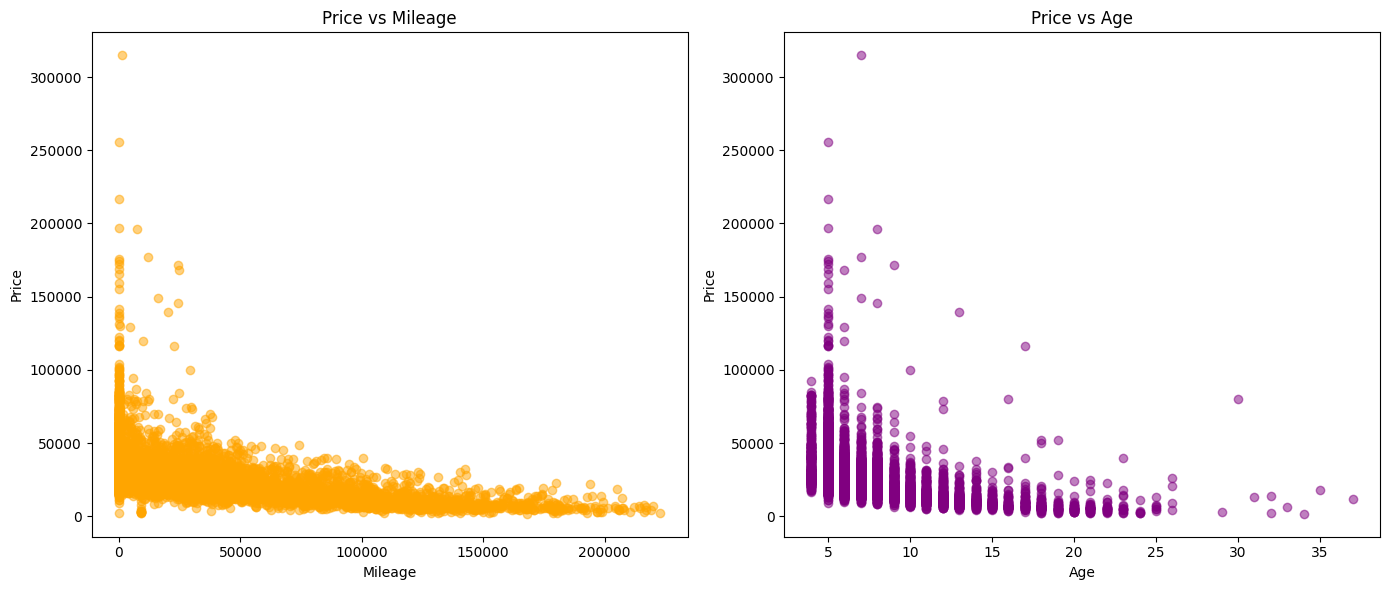



2.2 Interactions among features
New features capture real-world relationships that raw data can’t show:
- Seasonality: Car demand could change by season, which could affect the price. Adding seasonality flags lets the model learn price patterns tied to the time of year a car is listed. The columns include `is_winter_listing`, `is_summer_listing`, `is_spring_listing`, and `is_fall_listing`

- Value metrics: These capture how a car’s value changes with age and usage.
   - `depreciation_rate` estimates how much value a car loses relative to its age and mileage.
   - `value_per_hp` links performance (horsepower) to engine size, showing efficiency or engineering quality.
   
   
   Together, they help model how value and performance interact over time.

- Performance ratios: These quantify how well the car performs and how efficient it is:
   - `power_to_weight` shows acceleration potential.
   - `torque_hp_ratio` captures how torque relates to power output.
   - `fuel_efficiency_avg` measures overall fuel economy.
   - `displacement_per_hp` and `displacement_per_cylinder` reveal engine design efficiency.
   - `displacement_per_cylinder` describes engine design and smoothness. Larger displacement per cylinder typically means higher torque and fuel use, while smaller values imply refinement and efficiency.

   
   These features help the model distinguish between performance cars, economy cars, and inefficient designs.

- Market signal: These features show market behavior:
   - `market_urgency` = daysonmarket × savings_amount identifies listings that have been on the market too long but heavily discounted, often signs of motivated sellers or overpriced vehicles.
   - `new_car_age_interaction` links “new” status with age, showing that even new cars lose value as time passes.

- Size: 
   - `interior_space`: Combines `front_legroom` and `back_legroom` to reflect passenger comfort and vehicle size, a key factor in pricing, especially for family or luxury cars.

- Efficiency:    
   - `fuel_economy_diff`: Shows the difference between highway and city fuel efficiency. A small gap means consistent efficiency (common in hybrids), while a large gap often indicates performance tuning or inefficiency.

- Geographic factor:
   - `climate_proxy` This feature measures how far a car’s listing location is from a moderate climate. As we know the market dynamics from univariate analysis, areas far from 40 latitude tend to have more extreme climates. This affects vehicle demand and condition.

- Power interation:
   - `horsepower_age_interaction`: Captures how engine power interacts with age — performance value drops faster in older, high-powered cars. This helps the model reflect real-world depreciation for powerful vehicles.


Finally, the function drops unused columns to prevent redundancy.

---
## Task 3: Fit and tune predictive models, submit predictions & win competition

**Total Marks: 8**

For this task, you should not create any new features and must rely on the variables constructed in Task 2.  


1. Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)

2. Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (1 marks)
   
3. Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

4. Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)

5. Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   

- Hints:
    - Make sure your Python code works so that your results can be replicated by the marker
    - You will receive the mark of zero for this Task if your code does not produce the forecasts uploaded to Kaggle
    - Make sure you clearly explain each step you do both in Markdown and in your presentation.  



Student in charge of this task: `Quoc Phong Nguyen`

In [21]:
# Import all necessary libraries for Task 3
from sklearn.metrics import mean_absolute_percentage_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Question 1: Perform key EDA
Perform some EDA to measure the relationship between the features and the target variable, and carefully explain your findings. (2 marks)

In [22]:
# Select all columns except 'vin' for EDA analysis
df_train_num = df_train.select_dtypes(include='number')

#### Explore correlation between `price` and all features in absolute value

In [23]:
corr_with_price = df_train_num.corr()['price'].abs().sort_values(ascending=False)
corr_with_price

price                             1.00
horsepower                        0.63
torque_lbft                       0.62
power_hp                          0.60
power_to_weight                   0.53
depreciation_rate                 0.51
brand_avg_price                   0.51
year                              0.47
age                               0.47
log_mileage                       0.45
cylinders_num                     0.44
is_new                            0.43
new_car_age_interaction           0.43
width                             0.41
wheel_system_FWD                  0.39
wheelbase                         0.39
engine_displacement               0.38
highway_fuel_economy              0.38
fuel_efficiency_avg               0.37
city_fuel_economy                 0.35
cylarr_type_V                     0.35
cylarr_type_I                     0.34
height                            0.32
franchise_dealer                  0.31
age_cubed                         0.31
value_per_hp             

We explore the correlation between the target variable `price` versus all available features in the train dataset. We use the absolute value and sort the correlation in descending order to clearly see the most correlated features. It can be seen that several features have a correlation of 0.5 or higher with the target variable, such as brand_avg_price, depreciation_rate, horsepower, power_hp and torque_lbft. These features are likely to be important predictors of the target variable `price`.

#### Explore correlations among all features in the training dataset

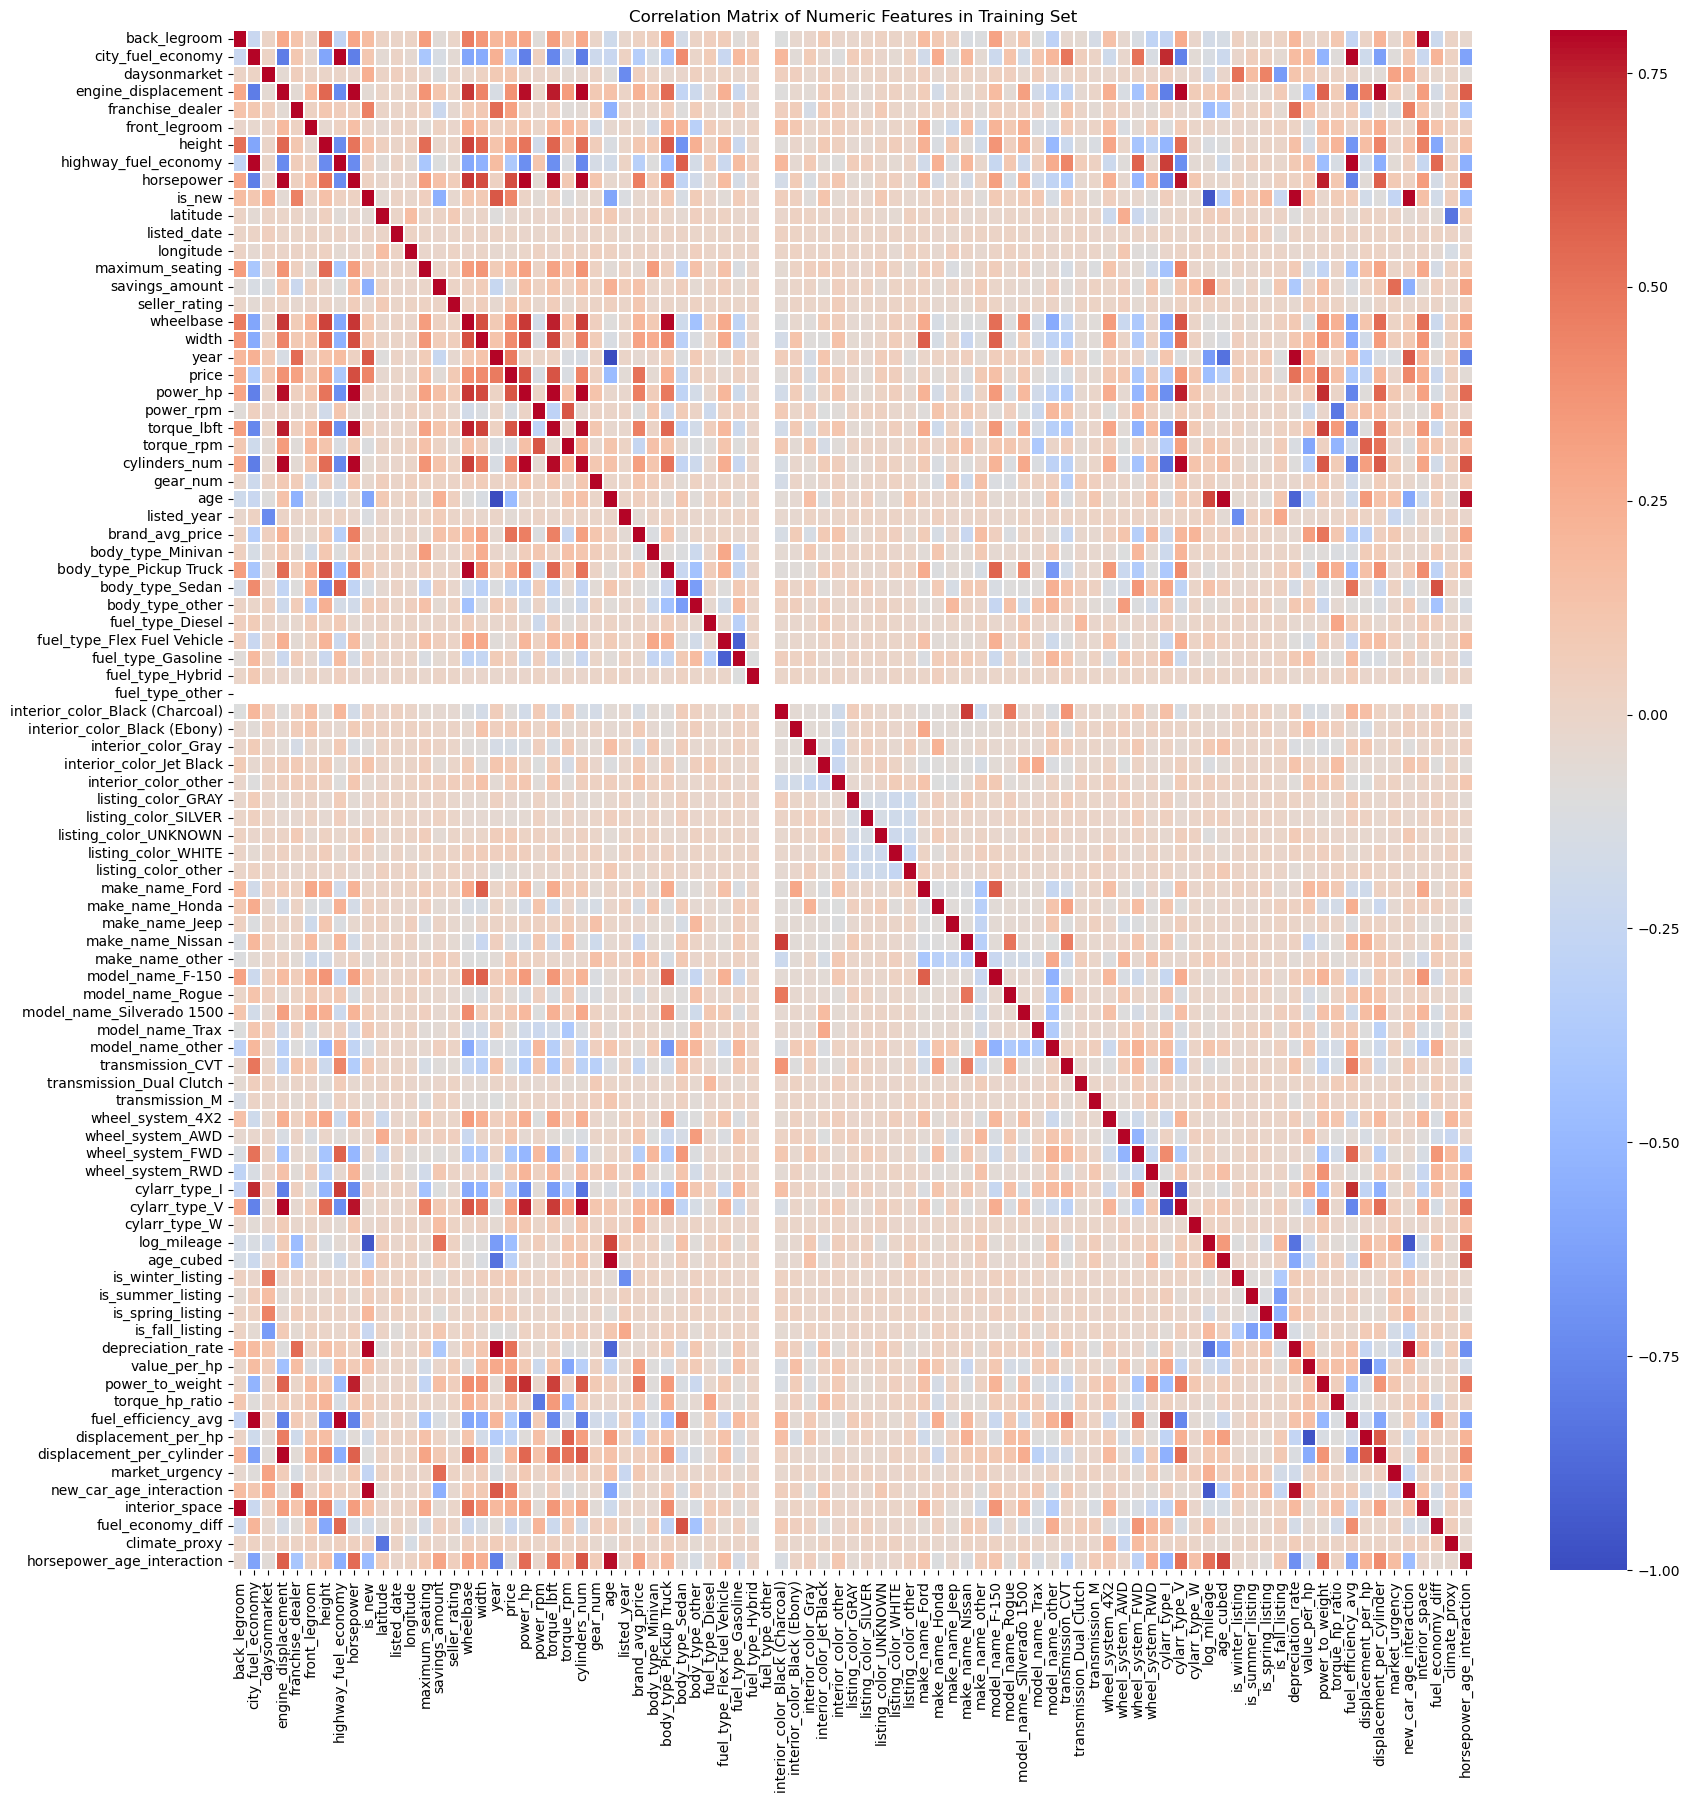

In [24]:
# Compute the correlation matrix for all numeric features in the training dataset
corr_matrix = df_train_num.corr()


plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.1, vmax = .8)
plt.title('Correlation Matrix of Numeric Features in Training Set')
plt.show()


We calculated the correlation matrix of all variables in the training dataset. We can observe the relationship between all features rather than just the target variable `price`. Some features have high correlation with each other and with the target. However, majority of dummy variables that we created based on original categorical variables have very low values of correlation. Noticeably, there is one variable `fuel_type_other` showing no correlation at all with any feature in the dataset. This observation should be taken into consideration when we move to the next steps of analysis and building machine learning models.

#### Explore distribution of target variable `price`

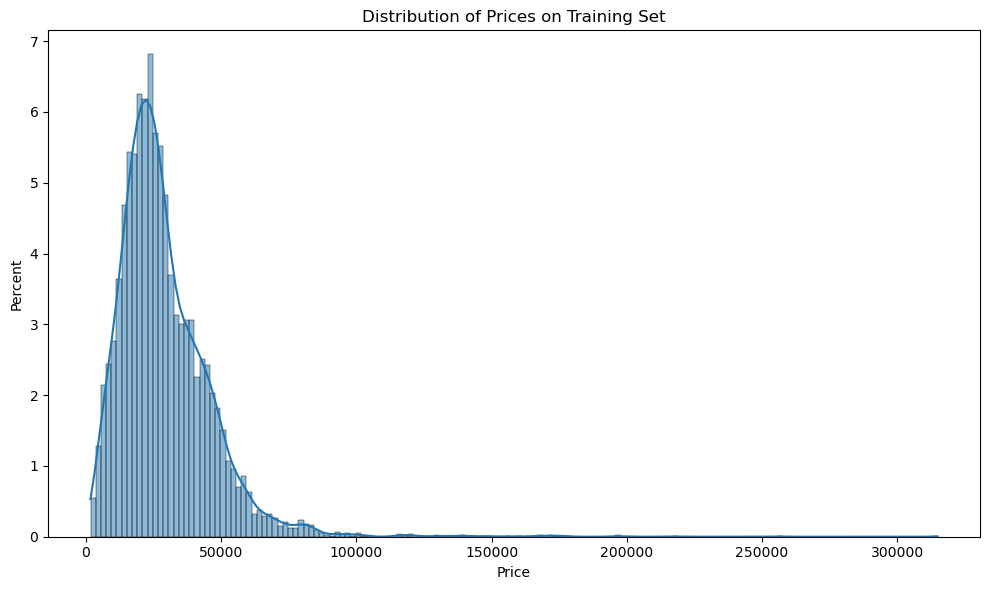

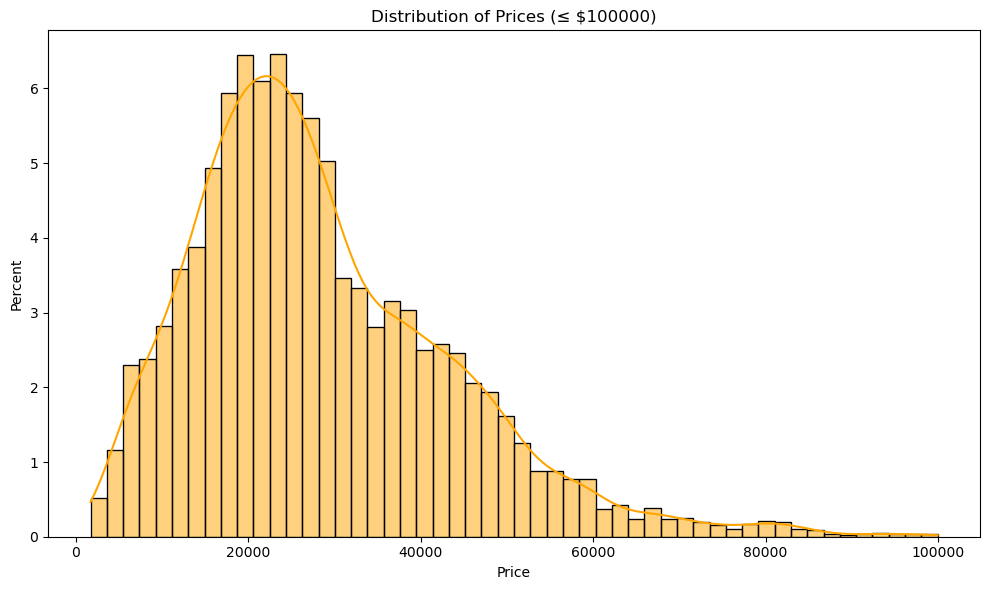

In [25]:
# Plot the distribution of the target variable `price`
plt.figure(figsize=(10,6))
sns.histplot(df_train_num['price'], stat = 'percent', kde=True)
plt.title('Distribution of Prices on Training Set')
plt.xlabel('Price')
plt.ylabel('Percent')
plt.tight_layout()
plt.show()

# Zoom in the histogram to focus on car prices less than or equal to 100000
plt.figure(figsize=(10,6))
sns.histplot(df_train_num[df_train_num['price'] <= 100000]['price'], stat='percent', kde=True, color='orange')
plt.title('Distribution of Prices (≤ $100000)')
plt.xlabel('Price')
plt.ylabel('Percent')
plt.tight_layout()
plt.show()


- As we can see from the histograms of `price` above, prices are strongly right-skewed, with a clear majority of values concentrated around $20,000 to $30,000. This right skew indicates that while most cars are in the lower price range, there are occasional high-value outliers that pull the mean significantly above the median.
- Because of this pattern in the target variable, we should consider applying a log transformation to price. This transformation would help compress the high-price tail and reduce the influence of extreme outliers on model fitting, avoiding the situation when models can perform well on low-to-mid-range cars but underperform on high-value cars.

#### Explore pairplots between features and `price`

After conducting a preliminary examination of all pairplots, we will further explore some potential variables in relation to price.

##### Explore `horsepower` and `torque_lbft`

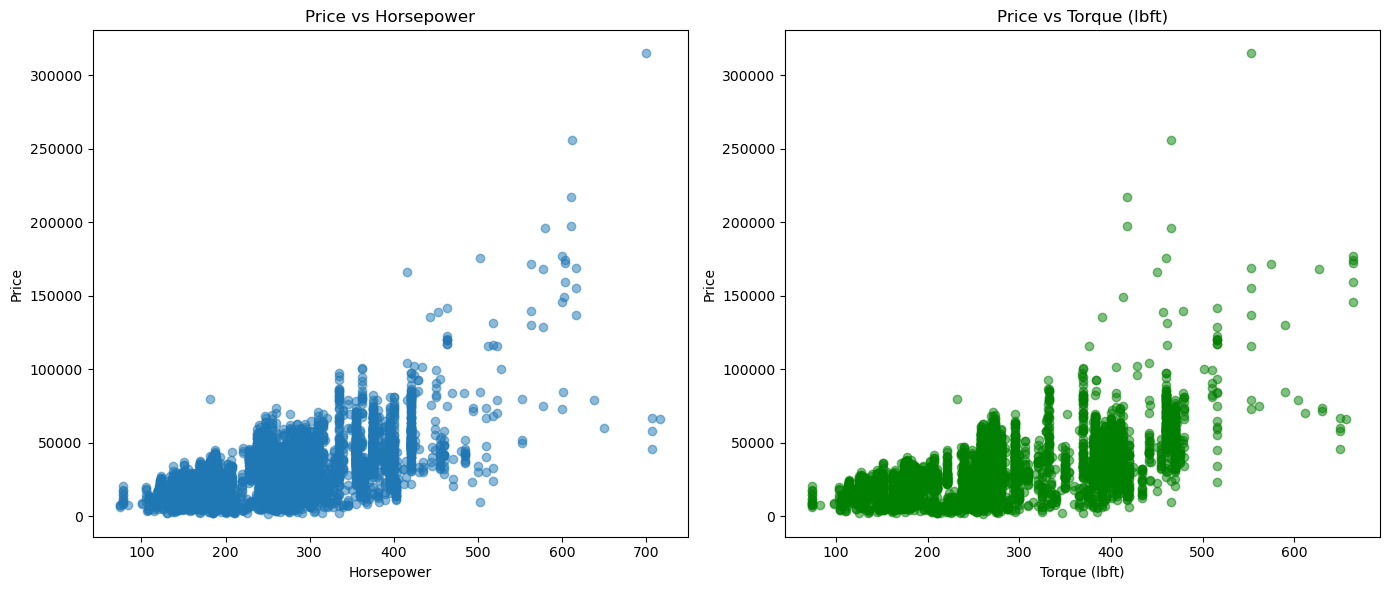

In [26]:
# Explore `horsepower` and `torque_lbft`
plt.figure(figsize=(14, 6))

# Scatter plot: horsepower vs price
plt.subplot(1, 2, 1)
plt.scatter(df_train_num['horsepower'], df_train_num['price'], alpha=0.5)
plt.title('Price vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Price')

# Scatter plot: torque_lbft vs price
plt.subplot(1, 2, 2)
plt.scatter(df_train_num['torque_lbft'], df_train_num['price'], color='green', alpha=0.5)
plt.title('Price vs Torque (lbft)')
plt.xlabel('Torque (lbft)')
plt.ylabel('Price')

plt.tight_layout()
plt.show()



The two scatter plots demonstrate the relationships between `horsepower` and `torque_lbft` with price:
-  For `horsepower`: The chart clearly shows a positive trend with higher horsepower values consistently associated with higher prices. This indicates that cars with greater horsepower are more expensive. Beyond 500 hp, the relationship becomes more dispersed, with extreme value reaching $300,000+, suggesting that ultra-high horsepower vehicles occupy a distinct luxury or performance segment. Overall, this consistent trend confirms that Horsepower is a predictive feature for pricing models.
- For `torque_lbft`: The scatter plot reveals a similar positive relationship with price, though with greater vertical dispersion than horsepower. This suggests that while torque is a factor in pricing, its impact is somewhat overshadowed by other factors.

##### Explore `mileage` and `age`

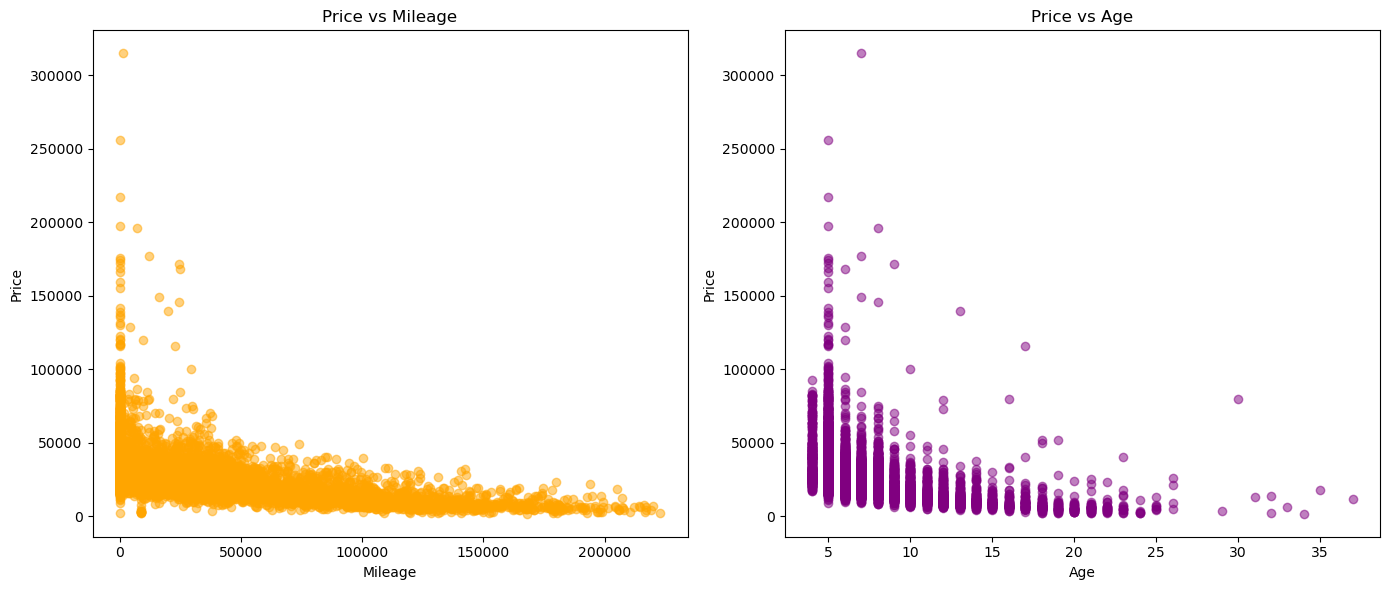

In [27]:
# Explore `mileage` and `age`
plt.figure(figsize=(14, 6))

# Scatter plot: mileage vs price (using original mileage from log_mileage)
plt.subplot(1, 2, 1)
original_mileage = np.expm1(df_train_num['log_mileage'])
plt.scatter(original_mileage, df_train_num['price'], alpha=0.5, color='orange')
plt.title('Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price')

# Scatter plot: age vs price
plt.subplot(1, 2, 2)
plt.scatter(df_train_num['age'], df_train_num['price'], alpha=0.5, color='purple')
plt.title('Price vs Age')
plt.xlabel('Age')
plt.ylabel('Price')

plt.tight_layout()
plt.show()


The two plots above examine the relationship of `price` against `mileage` and `age`:
- For `mileage`: The scatter plot shows a negative relationship between mileage and price. Vehicles with low mileage (0-50,000 miles) have significantly higher prices, with premium vehicles reaching $300,000+. As mileage increases beyond 50,000 miles, prices decline sharply and stabilise in the $10,000-$50,000 range. By 150,000+ miles, vehicles are mostly priced under $25,000. This means that mileage is a critical depreciation factor with a clear inverse relationship to price.
- For `age`: The figure shows even sharper negative trend, with vehicle age being a critical depreciation driver. Newer vehicles (5-10 years old) have the widest price range, ranging from $10,000 to $300,000+, indicating significant variation in quality or condition at similar ages. However, as vehicles age (10+ years), prices decline dramatically, concentrating mostly under $50,000.

##### Explore `year` and `daysonmarket`

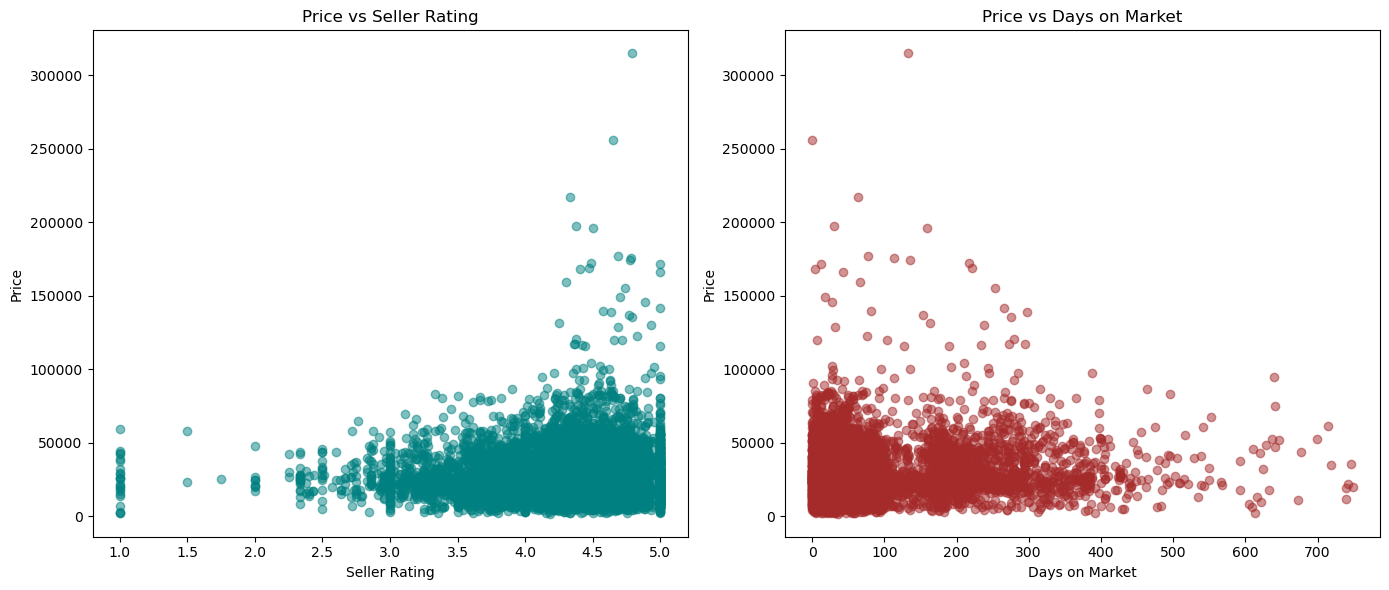

In [28]:
# Explore `seller_rating` and `daysonmarket`
plt.figure(figsize=(14, 6))

# Scatter plot: year vs price
plt.subplot(1, 2, 1)
plt.scatter(df_train_num['seller_rating'], df_train_num['price'], alpha=0.5, color='teal')
plt.title('Price vs Seller Rating')
plt.xlabel('Seller Rating')
plt.ylabel('Price')

# Scatter plot: daysonmarket vs price
plt.subplot(1, 2, 2)
plt.scatter(df_train_num['daysonmarket'], df_train_num['price'], alpha=0.5, color='brown')
plt.title('Price vs Days on Market')
plt.xlabel('Days on Market')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

Through the scatter plots above, we investigate the relationship between `price` and `seller_rating` & `daysonmarket`
- For `seller_rating`: There is no strong linear relationship between price and seller rating. Prices vary widely across all rating levels, and many high-value cars are offered by sellers with both mid and high ratings. The positive trend appears weak due to significant noise. This suggests seller rating alone is not a reliable determinant of price, and it should be considered in the combination with other predicting features.
- For `daysonmarket`: Similar to `seller_rating`, there is no clear trend linking price and days on market. Prices show wide variation at every market duration, with  many high-priced cars remaining unsold for both shor and long periods. The heavy noise observed in the figure implies that time on market does not have strong predictive power and pricing is driven by vehicle attributes rather than listing duration.

### Question 2: Select regression models
Choose and carefully explain 3 different machine learning (ML) regression models that you will apply in this competition. (1 marks)

In [29]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(df_train.drop(['price','vin'], axis=1), df_train['price'], test_size=0.2, random_state=42)

# Log transform the target variable
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

- In this step, we split the training data into training and validation sets with a 80/20 split.
- As discussed above the distribution of price is highly skewed. Thus, we apply log-transformation to the target variable (price) to make it more normally distributed. This also reduces the effect of outliers and stablises the variance. `np.log1p()` is used to safely handle zero/near-zero values. In our final results, predictions will be converted back to original scale using `np.expm1()` for MAPE calculation.
- In this analysis, we do not apply feature scaling by `Standard Scaler` because our primary models (Decision Tree and Random Forest) are tree-based algorithms that are not sensitive to the scale of the features. These models make splits based on feature thresholds, which are not affected by scaling. While we will use Linear Regression as a base model for comparison and this model can benefit from scaling, the overall improvement for the whole analysis is minimal and we prefer to keep the code consistent and simple.

#### Model 1: Linear Regression

- First, we select Linear Regression because it is the simplest model and provides a baseline benchmark for model performance before testing more complex methods. 
- The target variable `price` is continuous, and the exploratory analysis showed linear associations between price and several predictors through correlation matrices and scatter plots. Therefore, Linear Regression serves as a starting point to test if these linear relationships are sufficient to explain variation in car prices. 
- If the model performs well, it indicates that linear patterns capture pricing behaviour effectively. If performance is weak, it suggests that non-linear interactions and complex structures exist, which would justify moving to models such as Decision Tree and Random Forest.

In [30]:
# Create a Linear Regression model
lr = LinearRegression()

# Fit the model on the training data
lr.fit(X_train, y_train_log)

# Predict on the validation set
y_val_pred_log_lr = lr.predict(X_val)

# Convert predictions back to the original scale
y_val_pred_lr = np.expm1(y_val_pred_log_lr)

# Evaluate the model
mape_val_lr = mean_absolute_percentage_error(y_val, y_val_pred_lr)
r2_val_lr = r2_score(y_val, y_val_pred_lr)

print(f'MAPE on validation set for Linear Regression: {mape_val_lr:.5f}')
print(f'R2 on validation set for Linear Regression: {r2_val_lr:.5f}')

MAPE on validation set for Linear Regression: 0.15323
R2 on validation set for Linear Regression: 0.82751


- Linear Regression achieves a validation MAPE of 15.32% and R2 score of 0.828, indicating it captures approximately 83% of price variance but still has notable prediction errors.
- This moderate performance suggests that while linear relationships exist, they are insufficient to fully explain price variation.
- Non-linear relationships and interactions between features likely contribute to the remaining variance, therefore we should try other non-linear models.

#### Model 2: Decision Tree Regressor

- Next, we employ a Decision Tree Regressor to capture potential non-linear relationships in the data. Decision Tree can model complex interactions between features without requiring linear assumptions or feature scaling.
- As the EDA suggested possible non-linear effects in car attributes, a tree-based model provides a suitable step after Linear Regression. 
- If the Decision Tree outperforms the linear model, it indicates that price patterns depend on non-linear structures, otherwise the linear relationships dominate.

In [31]:
# Create a Decision Tree Regressor model
dt = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
dt.fit(X_train, y_train_log)

# Predict on the validation set
y_val_pred_log_dt = dt.predict(X_val)

# Convert predictions back to the original scale
y_val_pred_dt = np.expm1(y_val_pred_log_dt)

# Evaluate the model
mape_val_dt = mean_absolute_percentage_error(y_val, y_val_pred_dt)
r2_val_dt = r2_score(y_val, y_val_pred_dt)
print(f'MAPE on validation set for Decision Tree Regressor: {mape_val_dt:.5f}')
print(f'R2 on validation set for Decision Tree Regressor: {r2_val_dt:.5f}')



MAPE on validation set for Decision Tree Regressor: 0.16536
R2 on validation set for Decision Tree Regressor: 0.82793


- Based on the results above, we can see that the Decision Tree performs worse than the Linear Regression model, with a higher MAPE (0.165 vs 0.153) and only a marginal improvement in R2 (0.82793 vs 0.82751). 
- This outcome suggests that although the tree can model non-linear relationships, it likely overfits the training data and fails to generalise well to unseen observations on validation set.
- In this case, simple linear models can explain and predict the price more accurately than a single complex tree. However, we will try another tree-based model `Random Forest` to see if it can improve the performance. Random Forest is expected to reduce overfitting by combining multiple trees to achieve better generalisation and prediction accuracy.

#### Model 3: Random Foreest Regressor

- Finally, we select a Random Forest Regressor to improve accuracy and overcome the limitations of a single Decision Tree. 
- While one tree can overfit and struggle to generalise, a Random Forest builds many trees and averages their predictions. This approach makes the model more stable and better at capturing non-linear patterns in the data.
- After that, we will compare its performance with Linear Regression and single Decision Tree to evaluate what is the best model for our dataset.

In [32]:
# Create a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Fit the model on the training data
rf.fit(X_train, y_train_log)

# Predict on the validation set
y_val_pred_log_rf = rf.predict(X_val)

# Convert predictions back to the original scale
y_val_pred_rf = np.expm1(y_val_pred_log_rf)

# Evaluate the model
mape_val_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
print(f'MAPE on validation set for Random Forest Regressor: {mape_val_rf:.5f}')
print(f'R2 on validation set for Random Forest Regressor: {r2_val_rf:.5f}')

MAPE on validation set for Random Forest Regressor: 0.11602
R2 on validation set for Random Forest Regressor: 0.91317


- These results indicate that the Random Forest model delivers a substantial improvement compared to both Linear Regression and the single Decision Tree.
- A MAPE of roughly 11.6% shows a much lower average prediction error, while an R2 score above 0.91 illustrates that the model explains most of the variation in car prices. This suggests that combining many trees can better capture non-linear patterns while maintaining strong generalisation to unseen data.
- Overall, Random Forest is selected as the main model for further tuning and refinement in the next stage of the analysis.

### Question 3: Train regression models
Train the models from the above question and tune their hyperparameters via cross-validation. Discuss the fitted weights, optimised hyperparameter values, and their training dataset predictive performance. (2 marks)   

- To enhance the Random Forest model’s predictive performance, we conduct hyperparameter tuning using GridSearchCV with 5-fold cross-validation.
- This approach evaluates different combinations of key parameters, including the number of trees, tree depth, minimum samples required for splits and leaves, and the number of features considered at each split.
- The aim is to identify the parameter set that minimises prediction error while maintaining strong generalisation.
- Because the model is trained on log-transformed prices, we define a custom scoring function that converts predictions back to the original scale before computing the Mean Absolute Percentage Error. This ensures accuracy is evaluated in real price terms rather than the log scale. 
- The scoring function is set so that lower error produces a better score, which means GridSearchCV returns a negative MAPE value. Hence, the reported best score is negated to present the true MAPE value in cross-validation results.

In [33]:
# Custom scorer to calculate MAPE on original scale
def mape_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_percentage_error(y_true, y_pred)

mape_scorer = make_scorer(mape_original_scale, greater_is_better=False)

# Create a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

# Initialise the GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1, 
    scoring= mape_scorer
)

# Train the model
rf_grid.fit(X_train, y_train_log)

# Print the best parameters and the corresponding MAPE
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best MAPE: {-rf_grid.best_score_:.5f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best MAPE: 0.11230


After 5-fold cross-validation, the best set of hyperparameters for Random Forest Regressor is:
- **n_estimators=500:** The model uses 500 decision trees in the ensemble. More trees reduce prediction variance through averaging and improve stability. Among the tested values (200, 300, 500), 500 trees achieved the best cross-validation performance, indicating the model benefits from a large ensemble for accurate price predictions.
- **max_depth=25**: Each tree can grow up to 25 levels deep. This relatively deep structure allows the model to capture complex non-linear patterns and interactions between features. The fact that this is the highest value tested suggests the data contains intricate relationships that require deeper trees to model effectively.
- **min_samples_split=2 and min_samples_leaf=1:** These low thresholds give trees maximum flexibility to create splits, allowing the model to capture complex patterns in the data. While this increases individual tree complexity and overfitting risk, the Random Forest mitigates this through averaging predictions across many individual trees.
- **max_features='sqrt':** At each split, the model randomly considers only "square root of all available features" (√85 ≈ 9 features) instead of all 85. This creates variety among the 500 trees, when each tree focuses on different parts of the data and learns different patterns. When we combine predictions from these different trees, the final prediction is more accurate because individual tree errors are reduced through averaging.

In [34]:
# Best parameters from GridSearchCV
best_params = {
    'max_depth': 25,
    'max_features': 'sqrt', 
    'min_samples_leaf': 1,
    'min_samples_split': 2, 
    'n_estimators': 500
}

# Create a Random Forest Regressor model with best parameters
rf_best = RandomForestRegressor(random_state=42, **best_params)

# Fit the model on the training data
rf_best.fit(X_train, y_train_log)

# Predict on the validation set
y_val_pred_log_rf = rf_best.predict(X_val)

# Convert predictions back to the original scale
y_val_pred_rf = np.expm1(y_val_pred_log_rf)

# Evaluate the model
mape_val_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
print(f'MAPE on validation set for Random Forest Regressor (Best Parameters): {mape_val_rf:.5f}')
print(f'R2 on validation set for Random Forest Regressor (Best Parameters): {r2_val_rf:.5f}')

MAPE on validation set for Random Forest Regressor (Best Parameters): 0.11568
R2 on validation set for Random Forest Regressor (Best Parameters): 0.90981


- After applying the optimised hyperparameters from GridSearchCV, the Random Forest model achieves a MAPE of 0.11568 on the validation set, compared with 0.11602 before tuning. 
- This represents a slight improvement, indicating that the baseline Random Forest model is already well-performed and the hyperparameter adjustments primarily served to refine rather than dramatically change its performance.
- Next, we will experiment with minor refinements based on feature importance to examine whether targeted adjustments can further improve performance.

In [35]:
# Store feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_best.feature_importances_
})

# Select the top 67 features manually
feature_importance.sort_values(by="Importance", ascending=False, inplace=True)
selected_features = feature_importance.head(67)['Feature'].values

# Create new DataFrames with only the selected features
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]

# Train the modified model on the selected features
rf_modified = RandomForestRegressor(random_state=42, **best_params)
rf_modified.fit(X_train_selected, y_train_log)

# Predict on the validation set
y_val_pred_log_rf_modified = rf_modified.predict(X_val_selected)

# Convert predictions back to the original scale
y_val_pred_rf_modified = np.expm1(y_val_pred_log_rf_modified)

# Evaluate the modified model
mape_val_rf_modified = mean_absolute_percentage_error(y_val, y_val_pred_rf_modified)
r2_val_rf_modified = r2_score(y_val, y_val_pred_rf_modified)

print(f'MAPE on validation set for Random Forest Regressor (Modified Model): {mape_val_rf_modified:.5f}')
print(f'R2 on validation set for Random Forest Regressor (Modified Model): {r2_val_rf_modified:.5f}')

MAPE on validation set for Random Forest Regressor (Modified Model): 0.11501
R2 on validation set for Random Forest Regressor (Modified Model): 0.91006


- To further refine model performance, we conduct feature selection based on Random Forest feature importance scores. The most influential predictors are ranked, and we manually test different cut-offs to identify an efficient subset. A selection of 67 top features produced the best result.
- Retraining the Random Forest model using the tuned hyperparameters and these selected features reduced the validation MAPE from 0.11568 to 0.11501, indicating an improvement. This suggests that focusing the model on the most informative variables helps minimise noise and enhances prediction performance.
- Therefore, the optimised parameter set from GridSearchCV together with the selected feature subset will be used for the final model.

### Question 4: Select best model
Select your best model, create predictions of the test dataset and submit your forecasts on Kaggle's competition page. Provide Kaggle ranking and score (screenshots) and comment on your performance in the competition. (2 marks)

- For the final stage, the optimised Random Forest model (best parameters + feature selection) is retrained using the entire training dataset to ensure maximum learning capacity, instead of the earlier train-validation split.
- After fitting the model on the full training data, predictions are made for the test set and converted back to the original price scale.
- Then the final resutls are formatted and saved to a CSV file for submission to the Kaggle competition.

In [36]:
# Prepare full training data
X_full = df_train.drop(['vin', 'price'], axis=1)
y_full_log = np.log1p(df_train['price'])

# Select top 67 features from full data
X_full_selected = X_full[selected_features]
X_test_selected = df_test.drop(['vin','price'], axis=1)[selected_features]

In [37]:
# Train final model on full data
rf_final = RandomForestRegressor(random_state=42, **best_params)
rf_final.fit(X_full_selected, y_full_log)

print("Final model trained on full training data")

Final model trained on full training data


In [38]:
# Predict on the test set
y_test_pred_log_rf_final = rf_final.predict(X_test_selected)

# Convert predictions back to the original scale
y_test_pred_rf_final = np.expm1(y_test_pred_log_rf_final)

# Create a separate df for test
test = pd.read_csv('test.csv')
test['price'] = y_test_pred_rf_final

# Adjust the format
price_data = test[['vin', 'price']]

# Save the output in the csv file.
price_data.to_csv('RandomForestRegressor_final.csv', index = False)
print("Ready to submit on Kaggle!")

Ready to submit on Kaggle!


#### Kaggle submission result

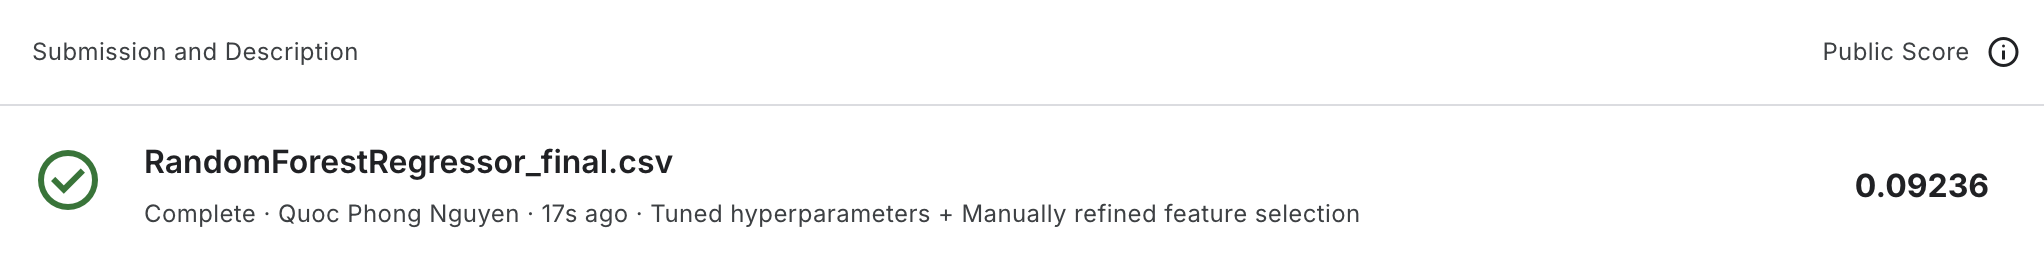

- Our final submission achieved a Kaggle public score of 0.09236, which is notably stronger than the validation performance observed during model development (approximately 0.11501 MAPE for the last trial).
- This improvement indicates that the model generalises well beyond the validation sample and benefits from training on the full dataset.
- The result also confirms that the combination of tuned hyperparameters and manually refined feature selection successfully enhanced the model’s predictive performance in the competition.

### Question 5: Improve ranking
Suggest ways to improve your ranking and implement them, providing further evidence from Kaggle (screenshots). (1 mark)   

To further improve model performance and ranking on Kaggle, several enhancement strategies were implemented and evaluated.

**1. Hybrid Hyperparameter and Feature Selection Tuning:**
- First, we combined hyperparameter tuning with manual refinement. GridSearchCV identified the optimal parameter combination, but the improvement was relatively small. Therefore, we complemented this with manual feature selection based on Random Forest feature importance scores. We tested multiple feature cut-offs rather than relying solely on the full feature set or a small subset. 
- For example, we initially supposed that selecting only the top 20-40 most important features would yield the best performance. However, this did not yield the expected results compared to the full feature set. This suggests that even features with lower importance scores may still contribute valuable information.
- After iterative testing, we found that the top 67 features provided the best performance with the lowest validation MAPE.

**2. Comprehensive Feature Engineering**
- Second, we improved data preparation by incorporating systematic feature engineering and thoughtful handling of missing values. Thanks to my teammate's brilliant idea on Task 2, we tested multiple imputation strategies for missing values using global and local statistics, including mean, median, and mode imputation, thereby selecting the approach that best preserved the underlying data distribution for each variable type while minimising information loss.
- More importantly, we created around 20 additional features beyond the original variables and one-hot encoded categorical features. These included interaction terms between key variables, and polynomial features such as squared and cubed terms to capture non-linear relationships. These engineered features enabled the model to capture complex, non-linear patterns in real-world car pricing that would be missed by using only the original variables.

**3. Alternative Model Exploration**
- Besides the standard models covered in this unit (Linear Regression, Decision Tree, and Random Forest), we explored LightGBM, a gradient boosting algorithm to understand if it could yield better performance on this dataset. 
- On Kaggle's public leaderboard, our LightGBM model achieved a MAPE of 0.06970 (6.97%), significantly outperforming our Random Forest model (9.2%). However, we acknowledge several concerns with this result, including potential overfitting given the large performance gap and the model's high complexity with 20,000 estimators and extensive number of leaves and depth. 
- Additionally, since LightGBM is not covered in this unit, we selected Random Forest as our final submission model. This exploration demonstrates that alternative models should be considered when building predictive models on real-world data, particularly when predictive performance is critical. The complete LightGBM implementation is provided in the Appendix for reference.

**4. Agile Iterative Development Approach**
- Throughout this competition, we adopted an agile and iterative approach by making 128 submissions to Kaggle to systematically test and refine our models. Rather than relying solely on validation set performance within our notebook, we continuously tested various model versions on Kaggle's test results to guide our refinements and ensure our improvements generalised to unseen data. 
- This iterative process involved testing different feature engineering approaches, hyperparameter settings and manual refinements on Kaggle. The received scores guided our incremental improvements to the final submission. As Kaggle allows selecting 2 submissions for final scoring, so we chose Random Forest (MAPE: 0.092) as our primary submission aligning with assignment requirements, and LightGBM (MAPE: 0.069) as our secondary submission demonstrating exploration of alternative techniques. 
- The total of 128 submissions demonstrates our systematic trial-and-refinement process, showing that iterative experimentation is effective for developing a robust predictive model and achieving optimal performance.

#### Evidence of improvement & ranking

**Final Kaggle Results:**
- Ranking: **Top 1** out of 113
- Public Score: 0.09236 (RandomForestRegressor) & 0.06970 (LightGBM)
- Private Score: 0.09547 (RandomForestRegressor) & 0.07157 (LightGBM)

**Final ranking**: Kaggle only displays the best one, which is the experiment of LightGBM and Total submissions.

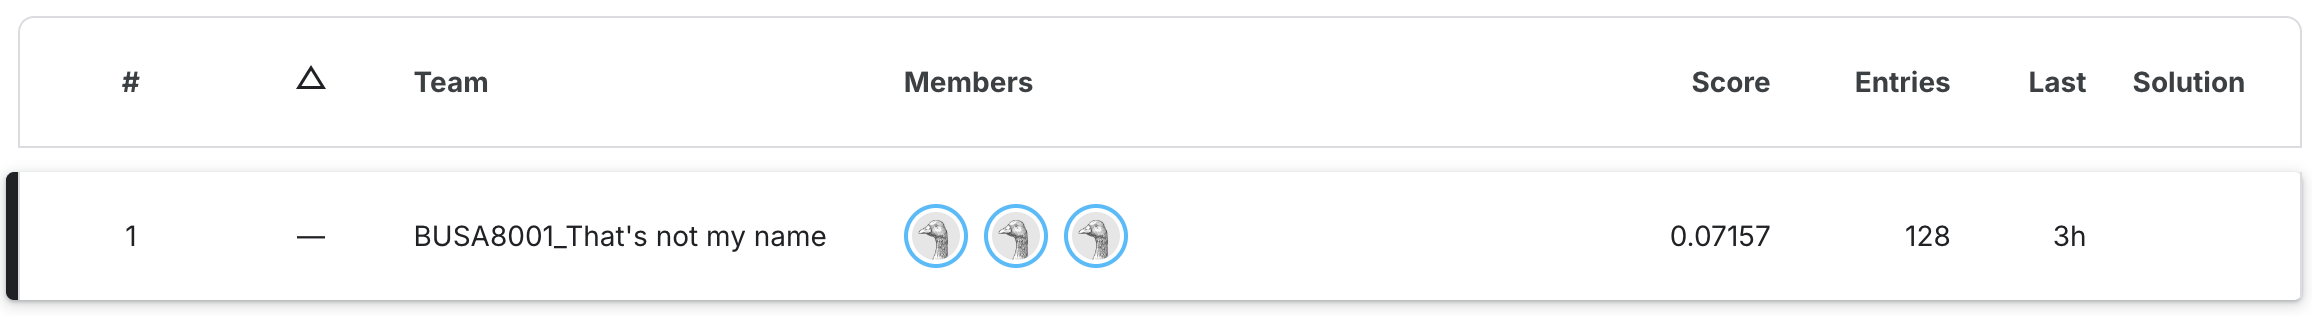

**Our group's two best submissions:** The final submission is RandomForestRegressor_final.csv, and the alternative is LightGBM_alternative.csv.

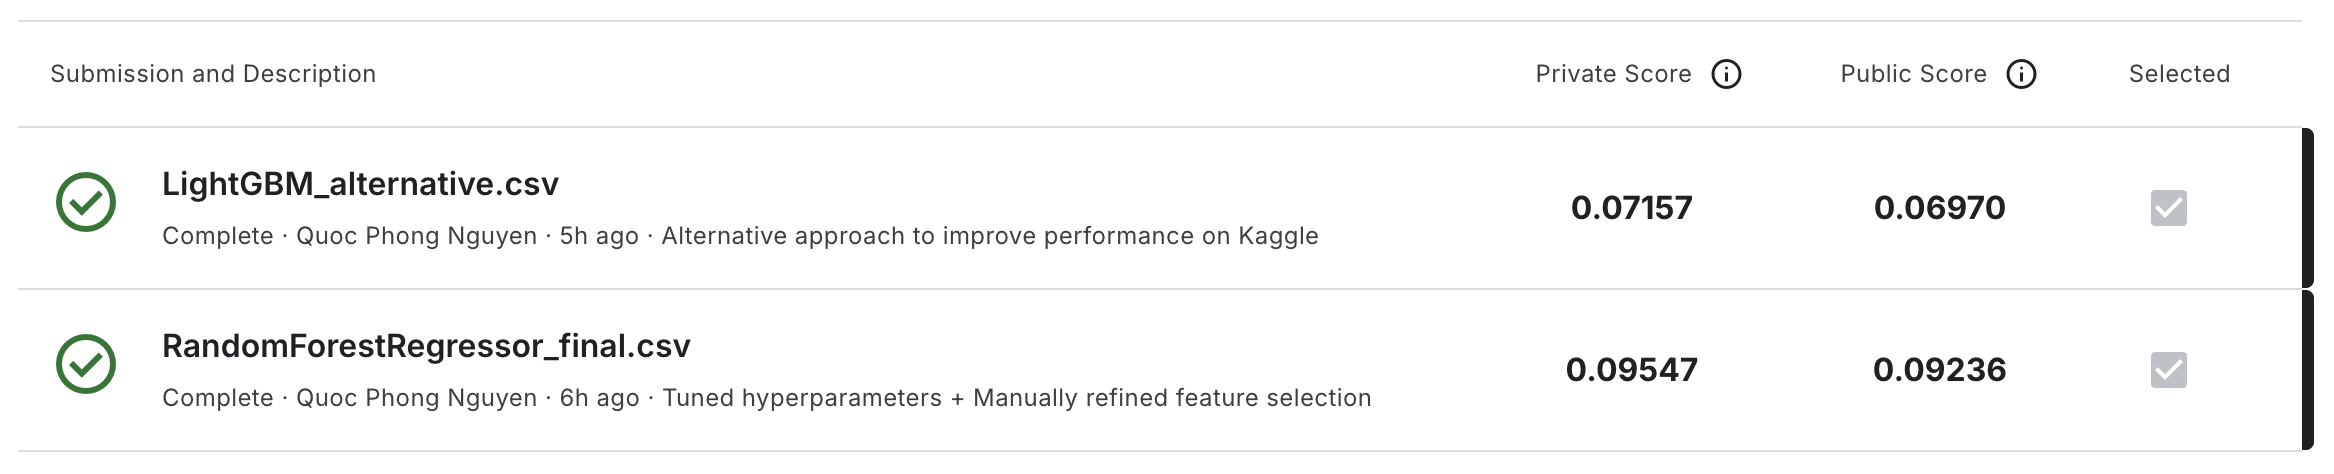

---
---
## Marking Criteria

To receive full marks your solutions must satisfy the following criteria:

- Problem Description: 8 marks
- Data Cleaning: 8 marks
- Building Forecasting models: 8 marks
- In Person Presentation: 6 marks
    - Duration less than 9 min, presentation skill and content
    - Each team member delivers a 3-minute presentation on their assigned task
    - All assignment questions must be discussed  
    - Your code must be readable in the presentation
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps
    - During the presentation, make sure that your Jupyter Notebook is clearly visible
- Forecasts correctly uploaded to Kaggle
- Python code is clean and concise
- Written explanations are provided in clear and easy to understand sentences
- The assignment notebook is well-organised and easy to follow
- Failure to meet the above marking criteria will result in a deduction of marks

---
---

### Appendix 1: Alternative Model Exploration

**LightGBM Model (Not used in the main submission):**

We explored LightGBM as an alternative gradient boosting approach. While this model achieved strong performance, we chose Random Forest for our final submission as it better aligns with the assignment requirements and still achieves competitive performance.

**Key differences from our Random Forest model:**
- Uses gradient boosting instead of bagging
- Requires feature scaling (StandardScaler applied)
- Employs DART boosting for better generalization
- Selects top 60 features based on importance

In [39]:
%%capture
pip install lightgbm

In [40]:
#### Alternative model to improve the result: LightGBM

from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

# Prepare data with scaling
lgbm_numeric_cols = df_train.select_dtypes(include='number').columns.drop('price')
lgbm_scaler = StandardScaler()

lgbm_df_train = df_train.copy()
lgbm_df_test = df_test.copy()

lgbm_df_train[lgbm_numeric_cols] = lgbm_scaler.fit_transform(lgbm_df_train[lgbm_numeric_cols])
lgbm_df_test[lgbm_numeric_cols] = lgbm_scaler.transform(lgbm_df_test[lgbm_numeric_cols])

lgbm_X_train = lgbm_df_train.drop(['vin', 'price'], axis=1)
lgbm_y_train_log = np.log1p(lgbm_df_train['price'])
lgbm_X_test = lgbm_df_test.drop(['vin', 'price'], axis=1, errors='ignore')

# Feature selection using LightGBM
lgbm_selector = LGBMRegressor(
    learning_rate=0.1,
    num_leaves=70,
    max_depth=10,
    n_estimators=2500, # Reduced for faster selection
    boosting_type='dart',
    random_state=1,
    force_col_wise=True,
    n_jobs=-1
)
lgbm_selector.fit(lgbm_X_train, lgbm_y_train_log)

# Select top 60 features
lgbm_feature_importance = pd.DataFrame({
    'Feature': lgbm_X_train.columns,
    'Importance': lgbm_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

lgbm_selected_features = lgbm_feature_importance.head(60)['Feature'].values
lgbm_X_train_selected = lgbm_X_train[lgbm_selected_features]
lgbm_X_test_selected = lgbm_X_test[lgbm_selected_features]

# Train final LightGBM model
lgbm_final = LGBMRegressor(
    learning_rate=0.1,
    num_leaves=65,
    max_depth=17,
    n_estimators=20000,
    boosting_type='dart',
    random_state=1,
    force_col_wise=True,
    n_jobs=-1
)
lgbm_final.fit(lgbm_X_train_selected, lgbm_y_train_log)

# Predict and evaluate
lgbm_y_train_pred = np.expm1(lgbm_final.predict(lgbm_X_train_selected))
lgbm_y_test_pred = np.expm1(lgbm_final.predict(lgbm_X_test_selected))

lgbm_mape_train = mean_absolute_percentage_error(lgbm_df_train['price'], lgbm_y_train_pred)
print(f'LightGBM Training MAPE: {lgbm_mape_train:.5f}')

# Save predictions
lgbm_test = pd.read_csv('test.csv')
lgbm_test['price'] = lgbm_y_test_pred
lgbm_test[['vin', 'price']].to_csv('LightGBM_alternative.csv', index=False)
print ("Alternative model ready!")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 5736
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 83
[LightGBM] [Info] Start training from score 10.114220
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 5614
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 60
[LightGBM] [Info] Start training from score 10.114220
LightGBM Training MAPE: 0.00265
Alternative model ready!


### Appendix 2: Other code assisting in the final submission

In [41]:
# ### Render image in notebook
# import base64

# with open('ranking.png', 'rb') as f:
#     encoded = base64.b64encode(f.read()).decode('utf-8')
    
# print(f'<img src="data:image/png;base64,{encoded}" width="600"/>')